# Multi-Asset Scenario Engine

A modular Python research prototype for **joint equity/rates/credit/FX scenario generation under the physical measure**, **multi-instrument horizon repricing**, and **portfolio tail-risk analysis**.

The notebook is designed around a market-risk workflow:

1. transform raw market data into cross-asset risk drivers;
2. simulate joint one-week scenarios under \(P\);
3. reconstruct horizon market states;
4. reprice equities, Treasury notes, corporate bonds, and FX forwards;
5. evaluate portfolio VaR, Expected Shortfall, tail contributions, and minimum-CVaR allocations.

The current stable release uses a **one-week horizon** and a **joint stationary block-bootstrap** as the default dynamics. This choice is intentionally parsimonious for the available common equity/rates/credit/FX sample, while a VAR(1) diagnostic remains available as a benchmark.

The implementation includes:

- a multi-sector US equity universe;
- selectable equity-premium engines: latent statistical, market proxy, FF3, and Carhart-style APT;
- a 10-tenor US Treasury curve factor block;
- a rating-bucket credit-spread / OAS factor block;
- an EUR/USD FX factor block;
- Treasury, corporate-bond, and FX-forward horizon repricing;
- walk-forward VaR coverage diagnostics;
- optional crisis-tail stress overlays calibrated from long-history Moody's Baa/Aaa credit-spread data;
- LP-based long-only minimum-CVaR portfolio construction.

The project is a **research prototype**, not a production market-risk system or a risk-neutral pricing library. Its purpose is to demonstrate a coherent cross-asset pipeline from risk drivers to simulated market states, instrument repricing, and portfolio tail-risk diagnostics.


## Research positioning

The notebook is structured as a **cross-asset scenario and horizon-repricing engine under the physical measure**.

The main modelling layers are:

1. an **equity-premium block** with selectable statistical, market-proxy, and observable-factor engines;
2. a **Treasury curve factor block** built from 10 key rates;
3. a **credit-spread block** built from rating-bucket OAS changes;
4. an **FX block** for currency-pair log returns;
5. a **joint scenario engine** based on block-bootstrap dynamics with VAR diagnostics;
6. a **horizon repricing layer** for equities, Treasury notes, corporate bonds, and FX forwards;
7. a **portfolio tail-risk layer** based on capital-normalized returns, VaR, Expected Shortfall, tail contributions, and LP minimum-CVaR optimisation.

The goal is not point forecasting. The goal is **joint scenario generation, horizon repricing, and portfolio risk analysis**.


In [1]:
# Core imports and global configuration
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from pandas_datareader import data as web

from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR

from scipy import sparse
from scipy.optimize import linprog
from scipy.stats import chi2

from pandas.tseries.offsets import BDay

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.rcParams["figure.figsize"] = (10, 6)

# Broad US equity prototype universe (multi-sector)
TICKERS = ["MSFT", "JPM", "XOM", "JNJ", "PG", "HD", "CAT", "NEM", "PLD", "DUK"]
SECTOR_MAP = {
    "MSFT": "Information Technology",
    "JPM": "Financials",
    "XOM": "Energy",
    "JNJ": "Health Care",
    "PG": "Consumer Staples",
    "HD": "Consumer Discretionary",
    "CAT": "Industrials",
    "NEM": "Materials",
    "PLD": "Real Estate",
    "DUK": "Utilities",
}

MARKET_PROXY = "SPY"

# richer Treasury key-rate grid (ascending tenor). These DGS* series are continuously
# available from FRED since well before START_DATE (DGS20 is intentionally excluded because it was
# discontinued 1987-1993 and only reintroduced in Oct-2020, which would create a large NaN gap and
# shrink the aligned sample). With 10 tenors the rates PCA compresses and the
# level/slope/curvature interpretation becomes meaningful rather than forced on 3 points.
RATE_TICKERS = ["DGS1MO", "DGS3MO", "DGS6MO", "DGS1", "DGS2", "DGS3", "DGS5", "DGS7", "DGS10", "DGS30"]
TENOR_YEARS = {
    "DGS1MO": 1.0 / 12.0,
    "DGS3MO": 0.25,
    "DGS6MO": 0.5,
    "DGS1": 1.0,
    "DGS2": 2.0,
    "DGS3": 3.0,
    "DGS5": 5.0,
    "DGS7": 7.0,
    "DGS10": 10.0,
    "DGS30": 30.0,
}

# Credit block: ICE BofA option-adjusted spreads (OAS) by rating bucket, ascending credit risk
# (AAA -> CCC). These form a credit-quality curve that the PCA compresses to a few factors
# (level / IG-HY slope / curvature) and that feeds corporate-bond repricing at Treasury-zero + OAS.
CREDIT_OAS_SERIES = {
    "BAMLC0A1CAAA": "AAA",   # ICE BofA AAA US Corporate OAS
    "BAMLC0A2CAA": "AA",     # ICE BofA AA US Corporate OAS
    "BAMLC0A3CA": "A",       # ICE BofA Single-A US Corporate OAS
    "BAMLC0A4CBBB": "BBB",   # ICE BofA BBB US Corporate OAS
    "BAMLH0A1HYBB": "BB",    # ICE BofA BB US High Yield OAS
    "BAMLH0A2HYB": "B",      # ICE BofA Single-B US High Yield OAS
    "BAMLH0A3HYC": "CCC",    # ICE BofA CCC & Lower US High Yield OAS
}
TARGET_CREDIT_EXPLAINED_VAR = 0.99

# Credit-parsimony setting: hard-cap the credit factors retained from the rating-bucket OAS curve.
# The buckets are highly collinear, so PC1 ~ credit level, PC2 ~ IG-HY slope, PC3 ~ curvature capture
# essentially all the variance; keeping all 7 would inject near-degenerate dimensions into the joint
# VAR. PC1 is also the systematic credit factor a later 1-year CreditMetrics view would reuse. Set to
# None to retain the full TARGET_CREDIT_EXPLAINED_VAR set (the full-factor behaviour).
CREDIT_MAX_FACTORS = 3

# Sample configuration
# IMPORTANT (data availability): as of April 2026 the FRED ICE BofA OAS series are licensed to
# expose only a rolling ~3 years of history (BAMLC0A4CBBB now spans roughly 2023-05 to 2026-05).
# To keep the credit block reproducible against live FRED, the whole sample lives on that recent
# window; all four blocks (equity, rates, Fama-French, credit) then share common dates. To run the
# original 2018-2022 / 2023-01-01 setup you would need a non-truncated credit source (e.g. Moody's
# seasoned Aaa/Baa yields DAAA/DBAA differenced against a Treasury tenor, a coarser 2-point curve).
START_DATE = "2023-05-15"
AS_OF_DATE = pd.Timestamp("2026-05-01")
DOWNLOAD_END = (AS_OF_DATE + pd.Timedelta(days=10)).strftime("%Y-%m-%d")

# Active equity engine: choose among
#   "latent_statistical"
#   "proxy_market"
#   "apt_ff3"
#   "apt_carhart"
ACTIVE_EQUITY_ENGINE = "apt_carhart"

# Scenario engine configuration
HORIZON_BDAYS = 5
N_SCENARIOS = 10_000
RNG_SEED = 42
VALIDATION_SEED = 2024          # independent seed for the out-of-sample (fresh-draw) check (implementation note)
BOOTSTRAP_EXPECTED_BLOCK = 10
TARGET_RATE_EXPLAINED_VAR = 0.995
TARGET_RESID_EXPLAINED_VAR = 0.95

# Parsimonious dynamics setting: joint-state dynamics. "block_bootstrap" drops the VAR(1) autoregressive term
# and resamples the demeaned joint drivers in stationary blocks (a block-bootstrap of the joint
# innovations around their mean); "var1" keeps the fitted VAR(1) dynamics. The VAR diagnostic cell
# reports the one-step R^2 that justifies the choice: when it is ~0 the VAR mean dynamics add little
# and block_bootstrap gives a near-identical distribution while removing k + k^2 parameters. Flip to
# "var1" to recover the pre-parsimony engine. The backtest and out-of-sample draw honour this flag.
DRIVER_DYNAMICS = "block_bootstrap"

# Robust portfolio search (min-CVaR is now an exact LP; alpha/max_weight are the live knobs)
CVAR_ALPHA = 0.05
CVAR_MAX_WEIGHT = 0.50

# Walk-forward VaR backtest configuration (implementation note). This is the most expensive cell: it refits
# the engine at each as-of date on live data. Defaults are modest so it completes in reasonable
# time; increase BACKTEST_N_DATES (and re-run) for more statistical power in the coverage tests.
BACKTEST_N_DATES = 40
BACKTEST_STEP_BDAYS = 5
BACKTEST_N_SCENARIOS = 2_000

# Treasury note setup
COUPON_RATE = 0.02
FACE_VALUE = 100.0
PAY_FREQ = 2

# Corporate bonds priced off Treasury-zero + the simulated OAS for their rating bucket. Coupons are
# set near prevailing same-rating yields so prices start close to par; what matters for the demo is
# that they reprice through BOTH the rate channel and the (equity-linked) credit-spread channel.
CORP_BONDS = [
    {"name": "CORP_BBB_7Y", "rating": "BBB", "coupon": 0.052, "maturity_years": 7},
    {"name": "CORP_BB_5Y", "rating": "BB", "coupon": 0.068, "maturity_years": 5},
]

REPRESENTATIVE_EQUITY = TICKERS[0]
REPRESENTATIVE_RATING = "BBB"

# FX block: currency-pair spot rates from FRED (long history, no truncation). DEXUSEU is USD per
# euro, so a long-EUR position gains when it rises. The block is written to take a *list* of pairs
# but is configured here with the single EUR/USD pair (the lightest FX exposure); add FRED codes to
# the mapping to extend it (e.g. DEXJPUS / DEXUSUK), at which point the PCA starts to compress.
FX_SERIES = {
    "DEXUSEU": "EURUSD",   # US dollars per euro
}
TARGET_FX_EXPLAINED_VAR = 0.99
FX_MAX_FACTORS = None       # cap on retained FX factors; None = one component budget per pair

# FX-exposed instrument: a long-EUR forward struck at-the-money at the valuation date, so its MTM is
# zero at inception and the one-week P&L is pure FX (spot move) plus USD discounting. Numeraire is
# USD. `foreign_funding_rate` is the EUR funding rate, held CONSTANT over the one-week horizon
# (covered interest parity) as a declared approximation: the forward-points / carry term is then
# fixed and at one week immaterial (order a few bp) next to ~100-150 bp of weekly spot volatility.
# It is a placeholder parameter whose one-week risk sensitivity is negligible. notional_foreign is
# in EUR; the USD notional (the capital base used to normalize the forward's return) is
# notional_foreign * spot.
FX_FORWARDS = [
    {"name": "FXFWD_EURUSD_3M", "pair": "EURUSD", "maturity_years": 0.25,
     "foreign_funding_rate": 0.020, "notional_foreign": 100.0},
]

# Crisis-tail overlay. The OAS / equity / FX windows are only ~3 calm years (the ICE BofA truncation),
# so the empirical bootstrap tail is calibrated to a period with no real crisis. Moody's seasoned
# Baa/Aaa yields (DBAA/DAAA) carry decades including every postwar crisis and are used to characterize
# how often and how severely credit blows out. The crisis overlay is a JOINT two-state regime applied
# in the simulator (a stress step amplifies the whole joint innovation, so a crisis co-moves all four
# asset classes). Two modes are provided:
#   * "regime_jump"    -- parametric: amplify by CRISIS_SCALE on a stress step.
#   * "moody_backbone" -- empirical: amplify by a real historical Baa-Aaa stress-day severity.
# CRISIS_MODE = "none" (default) leaves the engine calibrated to the calm-window sample; the calm
# validation still matches the sample. Turning a crisis mode ON deliberately makes the simulated tail
# FATTER than the calm sample -- that is the point. Set CRISIS_PROB / CRISIS_SCALE to None to use the
# Moody's-calibrated values, or to a number to override them.
MOODYS_SERIES = {
    "DAAA": "Aaa",
    "DBAA": "Baa",
}
MOODYS_START_DATE = "1986-01-01"        # long history; FRED daily Moody's series start in the mid-1980s
CRISIS_SIGMA_THRESHOLD = 4.0            # a daily Baa-Aaa move beyond this many calm-sigma is a stress day
CRISIS_MODE = "none"                    # "none" | "regime_jump" | "moody_backbone"
CRISIS_PROB = None                      # None -> use the Moody's-calibrated stress-day frequency
CRISIS_SCALE = None                     # None -> use the Moody's-calibrated stress/calm volatility ratio


In [2]:
# Utilities: data loading, factor preparation, risk-driver extraction, scenario generation, repricing, portfolio analytics

def download_market_data(tickers, market_proxy, rate_tickers, start_date, download_end):
    """Download adjusted-close equity prices, a market proxy, and FRED Treasury key rates."""
    all_equity_tickers = list(dict.fromkeys(list(tickers) + [market_proxy]))
    stock_raw = yf.download(
        all_equity_tickers,
        start=start_date,
        end=download_end,
        auto_adjust=False,
        progress=False,
        actions=False,
    )

    if isinstance(stock_raw.columns, pd.MultiIndex):
        if "Adj Close" not in stock_raw.columns.get_level_values(0):
            raise ValueError("Adjusted close prices not found in yfinance download output.")
        prices_all = stock_raw["Adj Close"].copy()
    else:
        prices_all = stock_raw.copy()
        if isinstance(prices_all, pd.Series):
            prices_all = prices_all.to_frame(name=all_equity_tickers[0])
        prices_all.columns = all_equity_tickers

    stock_prices = prices_all[tickers].copy()
    market_proxy_prices = prices_all[[market_proxy]].copy()
    rates_raw = web.DataReader(rate_tickers, "fred", start_date, download_end).astype(float) / 100.0
    return stock_prices, market_proxy_prices, rates_raw


def download_credit_oas(credit_oas_series, start_date, download_end):
    """Download ICE BofA option-adjusted credit spreads (OAS) by rating bucket from FRED.

    `credit_oas_series` is an ordered mapping {FRED_code: rating_label} sorted by ascending credit
    risk (AAA -> CCC), so the resulting columns form a credit-quality curve. FRED reports OAS in
    *percent*, so we divide by 100 to express spreads in decimals, consistent with the Treasury
    key-rate convention (a 1.50% OAS becomes 0.0150).

    NOTE ON DATA AVAILABILITY: as of April 2026 the ICE BofA OAS series on FRED are licensed to
    expose only a rolling ~3 years of history. The credit block therefore lives on a recent window
    (see START_DATE / AS_OF_DATE in the config cell). For a longer sample one would substitute a
    non-truncated source (e.g. Moody's seasoned Aaa/Baa yields DAAA/DBAA differenced against a
    Treasury tenor), at the cost of a coarser two-point credit curve.
    """
    codes = list(credit_oas_series.keys())
    oas = web.DataReader(codes, "fred", start_date, download_end).astype(float) / 100.0
    oas = oas.rename(columns=dict(credit_oas_series))
    # preserve the ascending-risk column order
    oas = oas[[credit_oas_series[c] for c in codes]]
    return oas


def download_fx_rates(fx_series, start_date, download_end):
    """Download FX spot rates from FRED (one column per currency pair).

    `fx_series` is an ordered mapping {FRED_code: pair_label}. FRED quotes these pairs as
    'US dollars per 1 unit of foreign currency' (e.g. DEXUSEU = USD per EUR), so each column is the
    price in USD of one unit of the foreign currency and a long-foreign position gains when the
    column rises. Unlike the ICE BofA credit series these spot series carry long history with no
    3-year truncation.
    """
    codes = list(fx_series.keys())
    fx = web.DataReader(codes, "fred", start_date, download_end).astype(float)
    fx = fx.rename(columns=dict(fx_series))
    fx = fx[[fx_series[c] for c in codes]]
    return fx


def compute_fx_log_returns(fx_rates):
    return np.log(fx_rates / fx_rates.shift(1)).dropna()


def download_moodys_credit(moodys_series, start_date, download_end):
    """Download Moody's seasoned corporate bond yields from FRED (long history, no 3-year truncation).

    `moodys_series` maps FRED codes to labels, e.g. {"DAAA": "Aaa", "DBAA": "Baa"}. These daily
    seasoned-yield series run back to the 1980s and carry every postwar credit crisis, so the
    Baa-Aaa spread is used as a long-history credit-stress backbone to calibrate how often and how
    severely credit blows out relative to the short, calm OAS window the main engine is fit on.
    Yields are in percent on FRED; divided by 100 to decimals here.
    """
    codes = list(moodys_series.keys())
    mood = web.DataReader(codes, "fred", start_date, download_end).astype(float) / 100.0
    mood = mood.rename(columns=dict(moodys_series))
    return mood


def compute_credit_crisis_calibration(moodys, horizon_bdays, aaa_label="Aaa", baa_label="Baa",
                                      calm_lookback_years=3, calm_sigma_threshold=4.0):
    """Calibrate empirical credit-crisis statistics from the long Moody's Baa-Aaa history.

    The Baa-Aaa seasoned-yield spread is a coarse (two-point, investment-grade) but very long credit
    risk proxy. We mark a day as a credit-stress day when its daily Baa-Aaa change exceeds
    `calm_sigma_threshold` times the volatility of a recent calm window, then summarize crises by:
      * crisis_prob  -- empirical fraction of days that are credit-stress days (a per-step crisis
        probability for the regime overlay);
      * crisis_scale -- ratio of stress-day to calm-day volatility (how much bigger crisis moves are);
      * dof          -- a Student-t tail index from the full-history excess kurtosis (6/(dof-4));
      * stress_magnitude_pool -- the realized stress-day move sizes (in multiples of the calm std),
        i.e. *real* historical crisis severities, used by the "moody_backbone" simulator mode.

    This is a credit-derived, joint stress calibration: real crises move all asset classes together,
    so the regime overlay applies the scale to the whole joint innovation, not credit alone. The
    coarse IG proxy understates how much high-yield blows out in a crisis (a documented limitation);
    the rating-bucket loadings still apply more of the systematic move to HY, but a true crisis would
    widen HY convexly beyond what the calm-window loadings imply.
    """
    baa_aaa = (moodys[baa_label] - moodys[aaa_label]).dropna()
    dchg = baa_aaa.diff().dropna()
    calm_start = dchg.index.max() - pd.DateOffset(years=calm_lookback_years)
    calm = dchg[dchg.index >= calm_start]
    calm_std = float(calm.std()) if len(calm) > 5 else float(dchg.std())
    if not np.isfinite(calm_std) or calm_std <= 0:
        calm_std = float(dchg.std())

    thresh = calm_sigma_threshold * calm_std
    stress_mask = dchg.abs() > thresh
    n_stress = int(stress_mask.sum())
    crisis_prob = float(stress_mask.mean())
    if n_stress > 5:
        stress_std = float(dchg[stress_mask].std())
        stress_pool = (dchg[stress_mask].abs() / calm_std).to_numpy()
    else:
        stress_std = calm_std * 5.0
        stress_pool = np.array([5.0])
    crisis_scale = stress_std / calm_std if calm_std > 0 else 5.0
    ek = float(dchg.kurtosis())
    dof = float(4.0 + 6.0 / ek) if ek > 0.1 else 8.0
    return {
        "baa_aaa_spread": baa_aaa,
        "daily_changes": dchg,
        "calm_std": calm_std,
        "stress_std": stress_std,
        "crisis_prob": crisis_prob,
        "crisis_scale": crisis_scale,
        "dof": dof,
        "stress_magnitude_pool": stress_pool,
        "n_stress_days": n_stress,
        "n_total_days": int(len(dchg)),
        "history_start": dchg.index.min(),
        "history_end": dchg.index.max(),
    }


def _normalize_ff_columns(columns):
    mapping = {}
    for col in columns:
        cleaned = re.sub(r"[^A-Za-z0-9]+", "_", str(col).strip()).upper().strip("_")
        mapping[col] = cleaned
    return mapping


def _ff_table_to_returns(df):
    """Convert raw Fama-French / momentum tables to *simple daily returns* (decimals).

    implementation note fix: the FF series are excess / long-short spread returns (MKT-RF, SMB, HML, MOM).
    Applying log1p to a zero-cost long-short spread has no clean interpretation and is
    inconsistent with combining the factor contributions *additively* in the excess-return
    reconstruction. We therefore keep them as simple, additive daily returns. At the daily scale
    log1p(x) ~= x, so this does not move the numbers materially; it only removes the conceptual
    mismatch. (RF is also a level return and is left in the same simple-return convention so that
    'equity excess = equity log-return - RF' uses exactly the same risk-free that MKT-RF embeds.)
    """
    out = df.copy()
    out.index = pd.to_datetime(out.index.astype(str))
    out = out.apply(pd.to_numeric, errors="coerce")
    if out.abs().median().max() > 0.50:
        out = out / 100.0
    return out


def download_fama_french_daily_factors(start_date, end_date):
    """Download daily Fama-French market/style factors plus the daily momentum factor.

    The series are converted to simple daily returns (see `_ff_table_to_returns`) so they can be
    combined additively with the log-return machinery used elsewhere in the notebook.
    """
    ff3 = web.DataReader("F-F_Research_Data_Factors_daily", "famafrench", start=start_date)[0]
    mom = web.DataReader("F-F_Momentum_Factor_daily", "famafrench", start=start_date)[0]

    ff3 = ff3.rename(columns=_normalize_ff_columns(ff3.columns))
    mom = mom.rename(columns=_normalize_ff_columns(mom.columns))

    ff3 = _ff_table_to_returns(ff3)
    mom = _ff_table_to_returns(mom)

    mom_col = None
    for candidate in ["MOM", "MOMENTUM", "MOM_FACTOR"]:
        if candidate in mom.columns:
            mom_col = candidate
            break
    if mom_col is None:
        mom_col = mom.columns[0]

    ff = ff3.join(mom[[mom_col]].rename(columns={mom_col: "MOM"}), how="left")

    keep = [c for c in ["MKT_RF", "SMB", "HML", "RF", "MOM"] if c in ff.columns]
    ff = ff[keep].sort_index().loc[:pd.Timestamp(end_date)]
    return ff.dropna(how="any")


def choose_effective_asof(stock_prices, market_proxy_prices, rates, ff_factors, as_of_date, credit=None, fx=None):
    common_dates = stock_prices.index.intersection(market_proxy_prices.index).intersection(rates.index).intersection(ff_factors.index)
    if credit is not None:
        common_dates = common_dates.intersection(credit.index)
    if fx is not None:
        common_dates = common_dates.intersection(fx.index)
    eligible = common_dates[common_dates <= as_of_date]
    if len(eligible) == 0:
        raise ValueError("No common market date available at or before the chosen AS_OF_DATE.")
    return eligible.max()


def align_market_data(stock_prices, market_proxy_prices, rates, ff_factors, effective_date, credit=None, fx=None):
    """Align all blocks on their common dates up to the effective date.

    Returns a 6-tuple (prices, market, yields, ff, credit, fx); `credit` and `fx` are None when the
    corresponding frame is not supplied, so the narrower (equity-rates, or equity-rates-credit)
    paths are unchanged.
    """
    prices = stock_prices.loc[:effective_date].dropna(how="any")
    market = market_proxy_prices.loc[:effective_date].dropna(how="any")
    yields = rates.loc[:effective_date].dropna(how="any")
    ff = ff_factors.loc[:effective_date].dropna(how="any")
    common_dates = prices.index.intersection(market.index).intersection(yields.index).intersection(ff.index)
    cr = None
    if credit is not None:
        cr = credit.loc[:effective_date].dropna(how="any")
        common_dates = common_dates.intersection(cr.index)
    fxr = None
    if fx is not None:
        fxr = fx.loc[:effective_date].dropna(how="any")
        common_dates = common_dates.intersection(fxr.index)
    if cr is not None:
        cr = cr.loc[common_dates]
    if fxr is not None:
        fxr = fxr.loc[common_dates]
    return (prices.loc[common_dates], market.loc[common_dates], yields.loc[common_dates],
            ff.loc[common_dates], cr, fxr)


def compute_equity_log_returns(prices):
    return np.log(prices).diff().dropna()


def compute_yield_changes(yields):
    return yields.diff().dropna()


def compute_spread_changes(spreads):
    """Daily changes in credit OAS levels (decimals), analogous to yield changes."""
    return spreads.diff().dropna()


def compute_excess_log_returns_daily(log_returns, rf_daily):
    """Excess log returns using a *daily* risk-free series (already per-day, in decimals).

    implementation note fix: equity excess returns now use the SAME daily risk-free that defines the
    Fama-French factors (the FF 'RF' column), instead of DGS2/252. This removes the double
    risk-free convention (DGS2 for the equity excess vs the FF RF embedded inside MKT-RF) and
    stops using a 2Y point as an overnight-rate proxy.
    """
    rf = rf_daily.reindex(log_returns.index).ffill()
    excess = log_returns.sub(rf, axis=0)
    return excess, rf


def compute_market_excess_log_returns_daily(market_prices, rf_daily):
    market_log_returns = np.log(market_prices.squeeze()).diff().dropna()
    rf = rf_daily.reindex(market_log_returns.index).ffill()
    market_excess = market_log_returns.sub(rf, axis=0)
    market_excess.name = f"{market_prices.columns[0]}_excess_log_return"
    return market_excess


def plot_time_series(df, title, ylabel=None):
    ax = df.plot(figsize=(11, 6), lw=1.2)
    ax.set_title(title)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.show()


def plot_histogram(series, title, xlabel):
    ax = pd.Series(series).plot(kind="hist", bins=60, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, alpha=0.3)
    plt.show()


def distribution_summary(series):
    s = pd.Series(series, dtype=float).dropna()
    return pd.Series({
        "mean": s.mean(),
        "std": s.std(),
        "q01": s.quantile(0.01),
        "q05": s.quantile(0.05),
        "median": s.median(),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "min": s.min(),
        "max": s.max(),
    })


def loss_summary_from_pnl(series, alpha=0.05):
    s = pd.Series(series, dtype=float).dropna()
    threshold = s.quantile(alpha)
    tail = s[s <= threshold]
    return pd.Series({
        "mean": s.mean(),
        "std": s.std(),
        "q01": s.quantile(0.01),
        "q05": s.quantile(0.05),
        "median": s.median(),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "VaR_95_loss": -threshold,
        "ES_95_loss": -tail.mean() if len(tail) > 0 else np.nan,
    })


def _compress_residual_block(residuals, resid_explained_var_target=0.95):
    resid_pca_full = PCA().fit(residuals)
    resid_cumvar = np.cumsum(resid_pca_full.explained_variance_ratio_)
    k_resid = int(np.searchsorted(resid_cumvar, resid_explained_var_target) + 1)
    k_resid = max(1, min(k_resid, residuals.shape[1] - 1))

    resid_pca = PCA(n_components=k_resid)
    resid_scores = pd.DataFrame(
        resid_pca.fit_transform(residuals),
        index=residuals.index,
        columns=[f"resid_pc{i+1}" for i in range(k_resid)],
    )

    resid_loadings = pd.DataFrame(
        resid_pca.components_.T,
        index=residuals.columns,
        columns=resid_scores.columns,
    )

    resid_explained_ratio = pd.Series(
        resid_pca.explained_variance_ratio_,
        index=resid_scores.columns,
        name="resid_explained_variance_ratio",
    )

    # PCA on the residuals discards the variance beyond the retained components. That
    # dropped idiosyncratic variance never re-enters the simulation, so single-name tails would be
    # understated. We measure, per asset, the standard deviation of the part of the residual NOT
    # captured by the retained PCs, and re-inject it as iid noise in the simulator.
    reconstructed = resid_scores.to_numpy() @ resid_loadings.to_numpy().T
    leftover = residuals.to_numpy() - reconstructed
    resid_idiosyncratic_std = pd.Series(
        leftover.std(axis=0, ddof=1),
        index=residuals.columns,
        name="resid_idiosyncratic_std",
    )

    return {
        "resid_scores": resid_scores,
        "resid_loadings": resid_loadings,
        "resid_explained_ratio": resid_explained_ratio,
        "resid_cum_explained_ratio": resid_explained_ratio.cumsum(),
        "resid_idiosyncratic_std": resid_idiosyncratic_std,
        "resid_pca": resid_pca,
    }


def build_factor_driven_equity_block(excess_returns, factor_df, block_name, resid_explained_var_target=0.95):
    common_dates = excess_returns.index.intersection(factor_df.index)
    y = excess_returns.loc[common_dates].copy()
    f = factor_df.loc[common_dates].copy()

    mu_excess = y.mean()
    mu_factors = f.mean()
    centered_y = y - mu_excess
    centered_f = f - mu_factors

    X = centered_f.to_numpy()
    Y = centered_y.to_numpy()
    beta_array = np.linalg.lstsq(X, Y, rcond=None)[0].T  # assets x factors

    betas = pd.DataFrame(beta_array, index=y.columns, columns=centered_f.columns)
    fitted = pd.DataFrame(X @ beta_array.T, index=y.index, columns=y.columns)
    residuals = centered_y - fitted
    asset_r2 = 1.0 - residuals.var(ddof=1) / centered_y.var(ddof=1)

    residual_block = _compress_residual_block(residuals, resid_explained_var_target)

    return {
        "engine_name": block_name,
        "factors": centered_f,
        "factor_means": mu_factors,
        "betas": betas,
        "residuals": residuals,
        "asset_r2": asset_r2,
        "mean_excess_returns": mu_excess,
        "excess_returns": y,
        **residual_block,
    }


def build_latent_statistical_equity_block(log_returns, rf_daily, resid_explained_var_target=0.95):
    excess_returns, short_rate_daily = compute_excess_log_returns_daily(log_returns, rf_daily)
    centered = excess_returns - excess_returns.mean()
    pca = PCA(n_components=1)
    factor_scores = pd.DataFrame(
        pca.fit_transform(centered),
        index=centered.index,
        columns=["latent_equity_factor"],
    )
    block = build_factor_driven_equity_block(
        excess_returns=excess_returns,
        factor_df=factor_scores,
        block_name="latent_statistical",
        resid_explained_var_target=resid_explained_var_target,
    )
    block["short_rate_daily"] = short_rate_daily.reindex(block["excess_returns"].index)
    block["latent_explained_variance"] = float(pca.explained_variance_ratio_[0])
    return block


def build_proxy_market_equity_block(log_returns, market_proxy_prices, rf_daily, resid_explained_var_target=0.95):
    excess_returns, short_rate_daily = compute_excess_log_returns_daily(log_returns, rf_daily)
    market_excess = compute_market_excess_log_returns_daily(market_proxy_prices, rf_daily)
    factor_df = market_excess.to_frame(name="market_erp_proxy")
    block = build_factor_driven_equity_block(
        excess_returns=excess_returns,
        factor_df=factor_df,
        block_name="proxy_market",
        resid_explained_var_target=resid_explained_var_target,
    )
    block["short_rate_daily"] = short_rate_daily.reindex(block["excess_returns"].index)
    block["market_excess"] = market_excess.reindex(block["excess_returns"].index)
    return block


def build_apt_equity_block(log_returns, rf_daily, ff_factor_panel, selected_factors, block_name, resid_explained_var_target=0.95):
    excess_returns, short_rate_daily = compute_excess_log_returns_daily(log_returns, rf_daily)
    factor_df = ff_factor_panel[selected_factors].copy()
    block = build_factor_driven_equity_block(
        excess_returns=excess_returns,
        factor_df=factor_df,
        block_name=block_name,
        resid_explained_var_target=resid_explained_var_target,
    )
    block["short_rate_daily"] = short_rate_daily.reindex(block["excess_returns"].index)
    block["selected_factors"] = list(selected_factors)
    return block


def summarize_equity_engine(block):
    return pd.Series({
        "n_equity_factors": block["factors"].shape[1],
        "n_residual_factors": block["resid_scores"].shape[1],
        "mean_asset_R2": block["asset_r2"].mean(),
        "median_asset_R2": block["asset_r2"].median(),
        "max_asset_R2": block["asset_r2"].max(),
        "min_asset_R2": block["asset_r2"].min(),
    }, name=block["engine_name"])


def _build_change_factor_model(changes, explained_var_target, prefix, mean_key, max_factors=None):
    """Generic PCA factor model for a panel of daily changes (yield changes or spread changes).

    Shared by the rates curve and the credit-spread curve (issue: a single asset-class adds a new
    risk-driver block of exactly this shape). Returns scores/loadings/mean plus explained variance.

    `max_factors` (credit-parsimony cap) hard-caps the retained factors. The rating-bucket OAS
    curve is highly collinear, so its PCA is near-degenerate: keeping all buckets injects ~7 weakly
    identified driver dimensions into an already large joint VAR. Capping to a few systematic factors
    (PC1 ~ credit level, PC2 ~ IG-HY slope, PC3 ~ curvature) keeps essentially all the variance while
    removing parameters; PC1 is also the systematic credit factor a later 1-year CreditMetrics view
    would reuse. The floor is 2 so level + slope are always present.
    """
    mean_chg = changes.mean()
    centered = changes - mean_chg

    pca_full = PCA().fit(centered)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    k = int(np.searchsorted(cumvar, explained_var_target) + 1)
    k = max(2, min(k, centered.shape[1]))
    if max_factors is not None:
        k = max(2, min(k, int(max_factors)))

    pca = PCA(n_components=k)
    scores = pd.DataFrame(
        pca.fit_transform(centered),
        index=centered.index,
        columns=[f"{prefix}_pc{i+1}" for i in range(k)],
    )
    loadings = pd.DataFrame(
        pca.components_.T,
        index=centered.columns,
        columns=scores.columns,
    )
    explained_ratio = pd.Series(
        pca.explained_variance_ratio_,
        index=scores.columns,
        name="explained_variance_ratio",
    )
    return {
        "scores": scores,
        "loadings": loadings,
        mean_key: mean_chg,
        "explained_ratio": explained_ratio,
        "cum_explained_ratio": explained_ratio.cumsum(),
        "n_factors": k,
        "pca": pca,
    }


def build_rates_factor_model(yield_changes, explained_var_target=0.995):
    return _build_change_factor_model(yield_changes, explained_var_target, prefix="rate", mean_key="mean_dy")


def build_credit_factor_model(spread_changes, explained_var_target=0.99, max_factors=None):
    """PCA factor model of the credit-spread curve (issue: credit block; parsimony cap).

    The rating-bucket OAS curve compresses to a few factors with a clean interpretation: pc1 is the
    overall credit-risk level (spreads widening/tightening together), pc2 the IG-vs-HY slope, etc.
    These credit factors are stacked into the joint state so the equity-credit (Merton-type)
    dependence is carried by the joint innovation bootstrap. `max_factors` caps the retained factors
     so the highly collinear curve does not inflate the joint VAR with near-degenerate
    dimensions; the buckets are still all reconstructed from the few factors via the loadings.
    """
    return _build_change_factor_model(spread_changes, explained_var_target, prefix="credit",
                                      mean_key="mean_dspread", max_factors=max_factors)


def build_curve_lsc_factors(key_rates):
    """Interpretable level / slope / curvature proxies, generalized to whatever tenors are present.

    with a richer curve we no longer hard-code DGS2/DGS5/DGS10. Assuming the columns are
    in ascending tenor order: level = average yield, slope = longest - shortest,
    curvature = 2*mid - shortest - longest.
    """
    cols = list(key_rates.columns)
    short, long = cols[0], cols[-1]
    mid = cols[len(cols) // 2]
    level = key_rates.mean(axis=1)
    slope = key_rates[long] - key_rates[short]
    curvature = 2.0 * key_rates[mid] - key_rates[short] - key_rates[long]
    return pd.DataFrame({
        "curve_level": level,
        "curve_slope": slope,
        "curve_curvature": curvature,
    }, index=key_rates.index)


def build_credit_lsc_factors(credit_spreads):
    """Interpretable credit level / quality-slope / curvature proxies across the rating buckets.

    Columns are assumed ordered by ascending credit risk (AAA -> CCC). level = average spread,
    slope = widest(HY) - tightest(IG), curvature = 2*mid - tight - wide.
    """
    cols = list(credit_spreads.columns)
    tight, wide = cols[0], cols[-1]
    mid = cols[len(cols) // 2]
    level = credit_spreads.mean(axis=1)
    slope = credit_spreads[wide] - credit_spreads[tight]
    curvature = 2.0 * credit_spreads[mid] - credit_spreads[tight] - credit_spreads[wide]
    return pd.DataFrame({
        "credit_level": level,
        "credit_quality_slope": slope,
        "credit_curvature": curvature,
    }, index=credit_spreads.index)


def build_fx_factor_block(fx_log_returns, explained_var_target=0.99, max_factors=None):
    """PCA factor block for a panel of daily FX log-returns (one column per currency pair).

    FX rates are NOT a redundant curve like the rating-bucket OAS, so for a small set of pairs this
    is essentially an identity (about one factor per pair); the PCA is kept for uniformity with the
    other blocks and so the block compresses gracefully if many pairs are added later. Unlike the
    rates / credit blocks, where the driver is a level *change* added onto a running level, the FX
    driver is a daily *log-return*: in the simulator it is cumulated over the horizon and then
    exponentiated onto the current spot level. `max_factors` caps the retained factors (None = one
    component budget per pair); the floor is 1 (a single pair yields a single factor).
    """
    mean_ret = fx_log_returns.mean()
    centered = fx_log_returns - mean_ret
    n_pairs = centered.shape[1]

    pca_full = PCA().fit(centered)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    k = int(np.searchsorted(cumvar, explained_var_target) + 1)
    cap = n_pairs if max_factors is None else min(int(max_factors), n_pairs)
    k = max(1, min(k, cap))

    pca = PCA(n_components=k)
    scores = pd.DataFrame(
        pca.fit_transform(centered),
        index=centered.index,
        columns=[f"fx_pc{i+1}" for i in range(k)],
    )
    loadings = pd.DataFrame(
        pca.components_.T,
        index=centered.columns,
        columns=scores.columns,
    )
    explained_ratio = pd.Series(
        pca.explained_variance_ratio_,
        index=scores.columns,
        name="explained_variance_ratio",
    )
    return {
        "scores": scores,
        "loadings": loadings,
        "mean_fx_logret": mean_ret,
        "explained_ratio": explained_ratio,
        "cum_explained_ratio": explained_ratio.cumsum(),
        "n_factors": k,
        "pca": pca,
    }


def build_joint_driver_matrix(equity_block, rates_block, credit_block=None, fx_block=None):
    parts = [
        equity_block["factors"],
        equity_block["resid_scores"],
        rates_block["scores"],
    ]
    if credit_block is not None:
        parts.append(credit_block["scores"])
    if fx_block is not None:
        parts.append(fx_block["scores"])
    drivers = pd.concat(parts, axis=1).dropna()
    return drivers


def build_var1_model(drivers):
    return VAR(drivers).fit(maxlags=1, trend="c")


def var_one_step_r2(var_res, drivers):
    """Per-equation in-sample one-step-ahead R^2 of the VAR(1) vs a constant-only baseline.

    implementation note diagnostic: if these R^2 are near zero, the VAR(1) mean dynamics add little and the
    simulated risk is effectively coming from the bootstrapped innovations + factor loadings, not
    from genuine cross-predictability. In that case the model could be simplified (drop the VAR and
    block-bootstrap the demeaned joint innovations) or regularized (Minkowski/ridge / block prior).
    """
    resid = var_res.resid
    y = drivers.loc[resid.index]
    r2 = 1.0 - resid.var(ddof=0) / y.var(ddof=0)
    return r2.sort_values(ascending=False)


def stationary_bootstrap_index_matrix(n_obs, n_paths, horizon, avg_block_length, rng):
    """Vectorized stationary bootstrap (Politis-Romano) index matrix, shape (n_paths, horizon).

    replaces the per-path Python loop. Same generative process as before: at each step,
    with probability 1/avg_block_length restart at a fresh uniform index, otherwise advance the
    previous index by one (mod n_obs). Only `horizon` vectorized iterations are needed.
    """
    p_restart = 1.0 / avg_block_length
    restart = rng.random((n_paths, horizon)) < p_restart
    restart[:, 0] = True
    fresh = rng.integers(0, n_obs, size=(n_paths, horizon))
    idx = np.empty((n_paths, horizon), dtype=int)
    idx[:, 0] = fresh[:, 0]
    for h in range(1, horizon):
        advanced = (idx[:, h - 1] + 1) % n_obs
        idx[:, h] = np.where(restart[:, h], fresh[:, h], advanced)
    return idx


def simulate_joint_horizon(var_res, resid_hist, last_state, equity_block, rates_block,
                           current_prices, current_key_rates, horizon_bdays, n_scenarios,
                           avg_block_length, rng_seed, daily_rf, resid_idio_std=None,
                           rate_floor=-0.02, credit_block=None, current_spreads=None,
                           credit_floor=1e-4, fx_block=None, current_fx=None,
                           dynamics="var1", demeaned_drivers=None, driver_mean=None,
                           crisis_mode="none", crisis_prob=0.0, crisis_scale=1.0,
                           crisis_pool=None, _boot_idx=None):
    """Vectorized one-week joint scenario simulation (implementation note).

    Implementation notes:
      * fully vectorized across scenarios; only `horizon_bdays` steps are iterated, with batch
        matrix operations over the (n_scenarios, state_dim) state.
      * equity total-return reconstruction adds back a *constant* daily risk-free `daily_rf` (the
        FF daily RF at the as-of date) instead of the simulated DGS2/252, which unifies the
        risk-free convention with the factor block (implementation note). The variation of the short rate over
        a 5-business-day horizon is immaterial (order 1e-5), so treating it as constant is cleaner.
      * optional iid idiosyncratic noise `resid_idio_std` re-injects the residual variance that the
        PCA compression discards, so single-name tails are not understated (implementation note).

    Note: vectorization changes the order in which random numbers are consumed, so individual
    scenario paths differ from the loop-based implementation; the simulated *distribution* is unchanged.
    `_boot_idx` is an internal testing hook (pass a precomputed index matrix to make the run
    deterministic).
    """
    rng = np.random.default_rng(rng_seed)
    intercept = np.asarray(var_res.intercept, dtype=float)            # (k,)
    coef = np.asarray(var_res.coefs[0], dtype=float)                  # (k, k)
    resid_hist_arr = np.asarray(resid_hist, dtype=float)
    n_hist = resid_hist_arr.shape[0]

    # selectable joint-state dynamics. "var1" propagates the fitted VAR(1) and bootstraps
    # its residuals; "block_bootstrap" drops the autoregressive term entirely and resamples the
    # demeaned joint drivers in stationary blocks (state = driver_mean + demeaned_driver[boot]) -- a
    # block-bootstrap of the joint innovations around their mean. When the VAR one-step R^2 is ~0 the
    # two give near-identical distributions, but block_bootstrap removes the k + k^2 VAR parameters.
    # The factor reconstruction below (loadings -> daily returns/changes/spreads/FX, cumulated) is
    # identical in both modes; only the per-day state draw differs.
    if dynamics not in ("var1", "block_bootstrap"):
        raise ValueError(f"Unknown dynamics: {dynamics!r} (expected 'var1' or 'block_bootstrap')")
    if dynamics == "block_bootstrap":
        if demeaned_drivers is None or driver_mean is None:
            raise ValueError("block_bootstrap dynamics requires demeaned_drivers and driver_mean")
        dd_arr = np.asarray(demeaned_drivers, dtype=float)
        dmean_arr = np.asarray(driver_mean, dtype=float)
        n_innov = dd_arr.shape[0]
    else:
        n_innov = n_hist

    # Crisis-tail overlay (opt-in; the calm-window default is crisis_mode="none", which leaves the
    # draw byte-identical to the no-crisis engine). A crisis is a JOINT event, so on a crisis step the
    # entire joint innovation is amplified, blowing out equity, rates, credit and FX together:
    #   * "regime_jump": parametric -- amplify by a fixed `crisis_scale` (manual or Moody's-calibrated).
    #   * "moody_backbone": empirical -- amplify by a real historical crisis severity drawn from
    #     `crisis_pool` (Moody's Baa-Aaa stress-day move sizes, in multiples of the calm std).
    # `crisis_prob` is the per-step probability a scenario enters stress. The crisis RNG draws are
    # only consumed when crisis_mode != "none", so the off path does not disturb the base sequence.
    if crisis_mode not in ("none", "regime_jump", "moody_backbone"):
        raise ValueError(f"Unknown crisis_mode: {crisis_mode!r} (expected 'none', 'regime_jump', 'moody_backbone')")
    use_crisis = crisis_mode != "none" and crisis_prob > 0.0
    if crisis_mode == "moody_backbone" and use_crisis:
        crisis_pool_arr = np.asarray(crisis_pool, dtype=float) if crisis_pool is not None else np.array([float(crisis_scale)])
        if crisis_pool_arr.size == 0:
            crisis_pool_arr = np.array([float(crisis_scale)])

    asset_names = current_prices.index
    rate_names = current_key_rates.index
    n_stocks = len(asset_names)
    n_eq = equity_block["factors"].shape[1]
    n_resid = equity_block["resid_loadings"].shape[1]
    n_rate = rates_block["loadings"].shape[1]

    mu_excess = equity_block["mean_excess_returns"].to_numpy()        # (n_stocks,)
    beta = equity_block["betas"].to_numpy()                           # (n_stocks, n_eq)
    resid_load = equity_block["resid_loadings"].to_numpy()            # (n_stocks, n_resid)
    mu_dy = rates_block["mean_dy"].to_numpy()                         # (n_key_rates,)
    rate_load = rates_block["loadings"].to_numpy()                    # (n_key_rates, n_rate)

    # Credit block (optional). Stacked in the joint state AFTER the rates PCs, so its slice starts
    # at n_eq + n_resid + n_rate. Reconstruction mirrors the rates curve: spread changes are rebuilt
    # from the credit PCs and cumulated onto the current OAS levels. No extra RNG is consumed, so the
    # equity/rates draws are identical whether or not credit is present.
    use_credit = credit_block is not None and current_spreads is not None
    if use_credit:
        n_credit = credit_block["loadings"].shape[1]
        mu_dspread = credit_block["mean_dspread"].to_numpy()          # (n_ratings,)
        credit_load = credit_block["loadings"].to_numpy()            # (n_ratings, n_credit)
        spread_names = current_spreads.index
        spread_path = np.tile(current_spreads.to_numpy().astype(float), (n_scenarios, 1))
    else:
        n_credit = 0

    # FX block (optional). Stacked in the joint state AFTER the credit PCs, so its slice starts at
    # n_eq + n_resid + n_rate + n_credit (n_credit is 0 when no credit block is supplied). Unlike the
    # rates/credit curves, the FX driver is a daily *log-return*: it is cumulated over the horizon and
    # exponentiated onto the current spot level (one column per currency pair). No extra RNG is
    # consumed, so the equity/rates/credit draws are identical whether or not FX is present.
    use_fx = fx_block is not None and current_fx is not None
    if use_fx:
        n_fx = fx_block["loadings"].shape[1]
        mu_fx = fx_block["mean_fx_logret"].to_numpy()                 # (n_pairs,)
        fx_load = fx_block["loadings"].to_numpy()                     # (n_pairs, n_fx)
        fx_names = current_fx.index
        cum_fx = np.zeros((n_scenarios, len(fx_names)))
    else:
        n_fx = 0

    if resid_idio_std is None:
        idio_std = np.zeros(n_stocks)
    else:
        idio_std = np.nan_to_num(np.asarray(resid_idio_std.reindex(asset_names).to_numpy(), dtype=float), nan=0.0)

    if _boot_idx is None:
        boot_idx = stationary_bootstrap_index_matrix(n_innov, n_scenarios, horizon_bdays, avg_block_length, rng)
    else:
        boot_idx = np.asarray(_boot_idx, dtype=int)

    state = np.tile(np.asarray(last_state, dtype=float), (n_scenarios, 1))                 # (S, k)
    key_rate_path = np.tile(current_key_rates.to_numpy().astype(float), (n_scenarios, 1))  # (S, n_key_rates)
    cum_excess = np.zeros((n_scenarios, n_stocks))
    cum_log = np.zeros((n_scenarios, n_stocks))

    for h in range(horizon_bdays):
        if dynamics == "var1":
            innov = resid_hist_arr[boot_idx[:, h]]                    # (S, k)
        else:  # block_bootstrap
            innov = dd_arr[boot_idx[:, h]]                            # (S, k)

        if use_crisis:
            is_crisis = rng.random(n_scenarios) < crisis_prob         # (S,) per-scenario stress flag
            if crisis_mode == "regime_jump":
                cscale = np.where(is_crisis, crisis_scale, 1.0)
            else:  # moody_backbone: draw a real historical crisis severity for stressed scenarios
                cscale = np.ones(n_scenarios)
                n_c = int(is_crisis.sum())
                if n_c > 0:
                    cscale[is_crisis] = crisis_pool_arr[rng.integers(0, crisis_pool_arr.size, n_c)]
            innov = innov * cscale[:, None]                           # amplify the WHOLE joint innovation

        if dynamics == "var1":
            state = intercept[None, :] + state @ coef.T + innov      # (S, k)
        else:  # block_bootstrap: a block-resampled demeaned driver row + mean, no AR term
            state = dmean_arr[None, :] + innov                       # (S, k)

        eq_state = state[:, :n_eq]
        resid_state = state[:, n_eq:n_eq + n_resid]
        rate_state = state[:, n_eq + n_resid:n_eq + n_resid + n_rate]

        dy = mu_dy[None, :] + rate_state @ rate_load.T               # (S, n_key_rates)
        key_rate_path = np.clip(key_rate_path + dy, rate_floor, None)

        if use_credit:
            credit_state = state[:, n_eq + n_resid + n_rate:n_eq + n_resid + n_rate + n_credit]
            dspread = mu_dspread[None, :] + credit_state @ credit_load.T   # (S, n_ratings)
            spread_path = np.clip(spread_path + dspread, credit_floor, None)

        if use_fx:
            base = n_eq + n_resid + n_rate + n_credit
            fx_state = state[:, base:base + n_fx]
            daily_fx = mu_fx[None, :] + fx_state @ fx_load.T              # (S, n_pairs) daily FX log-returns
            cum_fx += daily_fx

        idio = resid_state @ resid_load.T                            # (S, n_stocks)
        if idio_std.any():
            idio = idio + rng.normal(0.0, 1.0, size=(n_scenarios, n_stocks)) * idio_std[None, :]

        daily_excess = mu_excess[None, :] + eq_state @ beta.T + idio  # (S, n_stocks)
        daily_log = daily_excess + daily_rf                          # constant rf add-back (implementation note)
        cum_excess += daily_excess
        cum_log += daily_log

    price_scenarios = current_prices.to_numpy()[None, :] * np.exp(cum_log)

    result = {
        "stock_excess_return_scenarios": pd.DataFrame(cum_excess, columns=asset_names),
        "stock_log_return_scenarios": pd.DataFrame(cum_log, columns=asset_names),
        "stock_price_scenarios": pd.DataFrame(price_scenarios, columns=asset_names),
        "key_rate_scenarios": pd.DataFrame(key_rate_path, columns=rate_names),
    }
    if use_credit:
        result["credit_spread_scenarios"] = pd.DataFrame(spread_path, columns=spread_names)
    if use_fx:
        fx_spot_scenarios = current_fx.to_numpy()[None, :] * np.exp(cum_fx)
        result["fx_log_return_scenarios"] = pd.DataFrame(cum_fx, columns=fx_names)
        result["fx_spot_scenarios"] = pd.DataFrame(fx_spot_scenarios, columns=fx_names)
    return result


def make_zero_curve_from_key_rates(key_tenors_years, key_rates):
    x = np.array([0.0] + list(key_tenors_years), dtype=float)
    y = np.array([key_rates[0]] + list(key_rates), dtype=float)
    def zero_rate(t):
        t = float(max(t, 0.0))
        return float(np.interp(t, x, y))
    return zero_rate


def generate_coupon_schedule(issue_date, maturity_date, freq=2):
    months_step = 12 // freq
    dates = []
    current = pd.Timestamp(issue_date) + pd.DateOffset(months=months_step)
    while current < pd.Timestamp(maturity_date):
        dates.append(current)
        current = current + pd.DateOffset(months=months_step)
    dates.append(pd.Timestamp(maturity_date))
    return pd.DatetimeIndex(dates)


def price_coupon_bond_from_curve(eval_date, payment_dates, key_rate_series, tenor_years,
                                 coupon_rate=0.02, face_value=100.0, freq=2, spread=0.0):
    """Dirty present value of a coupon bond off an interpolated zero curve.

    the tenor grid is now passed in (`tenor_years`) instead of hard-coding [2, 5, 10],
    so the pricer works with any set of FRED key rates.

    Credit block: an optional flat `spread` (the bond's option-adjusted credit spread, in decimals)
    is added to every interpolated zero rate, so a corporate bond is discounted at Treasury-zero +
    OAS. With spread=0.0 this is exactly the Treasury pricer (backward compatible).

    implementation note (declared approximations): the FRED CMT series (DGS*) are *par* bond-equivalent
    yields, not zero rates. Here we (a) linearly interpolate them across tenor and (b) treat the
    interpolated yields as *continuously-compounded zero rates* (exp(-z t) discounting). This
    conflates par-yield ~= zero-rate and bond-equivalent ~= continuous compounding and introduces a
    small systematic bias. It is acceptable for a prototype; a production version would bootstrap a
    zero curve from the par yields and respect the day-count / compounding convention. The OAS is
    likewise added as a flat continuously-compounded spread, consistent with that approximation.

    Returns the *dirty* (full) present value of all remaining cashflows; see `accrued_interest`
    for the clean/dirty split.
    """
    remaining_dates = payment_dates[payment_dates > pd.Timestamp(eval_date)]
    if len(remaining_dates) == 0:
        return float(face_value)
    times = np.array([(d - pd.Timestamp(eval_date)).days / 365.25 for d in remaining_dates], dtype=float)
    zero_curve = make_zero_curve_from_key_rates(tenor_years, np.asarray(key_rate_series, dtype=float))
    zero_rates = np.array([zero_curve(t) for t in times], dtype=float) + float(spread)
    discount_factors = np.exp(-zero_rates * times)
    cashflows = np.full(len(times), coupon_rate * face_value / freq, dtype=float)
    cashflows[-1] += face_value
    return float(np.sum(cashflows * discount_factors))


def reprice_corporate_bond_scenarios(eval_date, payment_dates, key_rate_scenarios, tenor_years,
                                     spread_scenarios, coupon_rate, face_value=100.0, freq=2):
    """Per-scenario dirty PV of a corporate bond, discounting at the simulated Treasury curve plus
    the simulated OAS for the bond's rating bucket.

    `key_rate_scenarios` is (S, n_key_rates) and `spread_scenarios` is the (S,) OAS path for the
    bond's rating; row s uses curve s and spread s jointly, so a scenario where equities fall and
    spreads widen together (the equity-credit link carried by the joint bootstrap) hits the
    corporate bond through both the rate and the spread channel. Light Python loop over scenarios:
    the pricer is a cheap interpolation, so this is not the simulation bottleneck.
    """
    curves = np.asarray(key_rate_scenarios, dtype=float)
    spreads = np.asarray(spread_scenarios, dtype=float)
    prices = np.empty(curves.shape[0], dtype=float)
    for s in range(curves.shape[0]):
        prices[s] = price_coupon_bond_from_curve(
            eval_date, payment_dates, curves[s], tenor_years,
            coupon_rate=coupon_rate, face_value=face_value, freq=freq, spread=float(spreads[s]),
        )
    return pd.Series(prices)


def accrued_interest(eval_date, payment_dates, coupon_rate=0.02, face_value=100.0, freq=2):
    """Accrued interest at eval_date (actual/actual within the current coupon period).

    included so portfolio P&L can be reported on a carry-consistent (clean vs dirty)
    basis, with clean = dirty - accrued. Over a one-week horizon with semiannual coupons this is
    immaterial (order 0.03 on a 2% note) but it is the technically-correct decomposition.
    """
    eval_date = pd.Timestamp(eval_date)
    future = payment_dates[payment_dates > eval_date]
    if len(future) == 0:
        return 0.0
    next_cpn = future[0]
    months_step = 12 // freq
    prev_cpn = next_cpn - pd.DateOffset(months=months_step)
    period_days = (next_cpn - prev_cpn).days
    accrued_days = max((eval_date - prev_cpn).days, 0)
    frac = accrued_days / period_days if period_days > 0 else 0.0
    return float(coupon_rate * face_value / freq * frac)


def price_fx_forward_mtm(eval_date, maturity_date, spot, usd_key_rate_series, usd_tenor_years,
                         strike, foreign_funding_rate, notional_foreign=1.0):
    """USD mark-to-market of a long-foreign FX forward (receive 1 foreign unit, pay `strike` USD per
    unit, at maturity), valued at `eval_date`.

    Decomposed as a long foreign zero-coupon bond minus a short USD zero-coupon bond:

        MTM_USD = notional_foreign * [ spot * exp(-r_foreign * tau) - strike * DF_USD(tau) ]

    where DF_USD(tau) = exp(-z_USD(tau) * tau) comes from the (simulated) USD zero curve and
    r_foreign is the foreign funding rate; tau is the year-fraction to maturity. `spot` is USD per
    one foreign unit (FRED convention, e.g. USD per EUR), so the long-foreign value rises with spot.

    Declared one-week approximation (covered interest parity): r_foreign is held constant over the
    horizon, so the forward-points / carry term is fixed and the P&L is driven by the spot move and
    USD discounting. At a one-week horizon the carry is immaterial (order a few bp) next to weekly
    spot volatility. This reuses the same continuously-compounded zero-curve convention (and its
    declared par-yield ~= zero-rate approximation) as the bond pricer.
    """
    eval_date = pd.Timestamp(eval_date)
    tau = max((pd.Timestamp(maturity_date) - eval_date).days / 365.25, 0.0)
    zero_curve = make_zero_curve_from_key_rates(usd_tenor_years, np.asarray(usd_key_rate_series, dtype=float))
    df_usd = float(np.exp(-zero_curve(tau) * tau))
    df_for = float(np.exp(-float(foreign_funding_rate) * tau))
    return float(notional_foreign) * (float(spot) * df_for - float(strike) * df_usd)


def atm_forward_fx_strike(eval_date, maturity_date, spot, usd_key_rate_series, usd_tenor_years,
                          foreign_funding_rate):
    """At-the-money forward FX rate (USD per foreign unit) by covered interest parity, so a freshly
    struck forward has zero MTM at inception:  K = spot * DF_foreign(tau) / DF_USD(tau)."""
    eval_date = pd.Timestamp(eval_date)
    tau = max((pd.Timestamp(maturity_date) - eval_date).days / 365.25, 0.0)
    zero_curve = make_zero_curve_from_key_rates(usd_tenor_years, np.asarray(usd_key_rate_series, dtype=float))
    df_usd = float(np.exp(-zero_curve(tau) * tau))
    df_for = float(np.exp(-float(foreign_funding_rate) * tau))
    return float(spot) * df_for / df_usd


def reprice_fx_forward_scenarios(eval_date, maturity_date, spot_scenarios, usd_key_rate_scenarios,
                                 usd_tenor_years, strike, foreign_funding_rate, notional_foreign=1.0):
    """Per-scenario USD MTM of the FX forward, using the simulated spot (row s) jointly with the
    simulated USD curve (row s), so an FX move and a Treasury move hit the forward together. Light
    Python loop; each valuation is a couple of interpolations, not the simulation bottleneck.
    """
    spots = np.asarray(spot_scenarios, dtype=float)
    curves = np.asarray(usd_key_rate_scenarios, dtype=float)
    mtm = np.empty(spots.shape[0], dtype=float)
    for s in range(spots.shape[0]):
        mtm[s] = price_fx_forward_mtm(
            eval_date, maturity_date, spots[s], curves[s], usd_tenor_years,
            strike=strike, foreign_funding_rate=foreign_funding_rate, notional_foreign=notional_foreign,
        )
    return pd.Series(mtm)


def rolling_horizon_log_returns(log_returns, window):
    return log_returns.rolling(window).sum().dropna()


def rolling_horizon_yield_changes(yield_changes, window):
    return yield_changes.rolling(window).sum().dropna()


def portfolio_metrics_from_instrument_returns(weights, instrument_returns, alpha=0.05):
    w = pd.Series(weights, index=instrument_returns.columns, dtype=float)
    w = w / w.sum()
    portfolio_return = instrument_returns.mul(w, axis=1).sum(axis=1)
    metrics = loss_summary_from_pnl(portfolio_return, alpha=alpha)
    metrics["mean_abs_weight"] = w.abs().mean()
    return portfolio_return, metrics


def inverse_vol_weights_from_scenarios(instrument_returns):
    vol = instrument_returns.std()
    inv_vol = 1.0 / vol.replace(0, np.nan)
    w = inv_vol / inv_vol.sum()
    return w.fillna(0.0)


def tail_contribution_table(portfolio_return, instrument_returns, weights, alpha=0.05):
    w = pd.Series(weights, index=instrument_returns.columns, dtype=float)
    w = w / w.sum()
    threshold = portfolio_return.quantile(alpha)
    tail_mask = portfolio_return <= threshold
    if tail_mask.sum() == 0:
        return pd.DataFrame()

    weighted_return_contrib = instrument_returns.mul(w, axis=1)
    avg_tail_return_contrib = weighted_return_contrib.loc[tail_mask].mean()
    avg_tail_loss_contrib = -avg_tail_return_contrib
    portfolio_es_loss = float(avg_tail_loss_contrib.sum())
    share = avg_tail_loss_contrib / portfolio_es_loss if portfolio_es_loss != 0 else np.nan

    return pd.DataFrame({
        "weight": w,
        "avg_tail_return_contribution": avg_tail_return_contrib,
        "avg_tail_loss_contribution": avg_tail_loss_contrib,
        "share_of_portfolio_ES_loss": share,
    }).sort_values("avg_tail_loss_contribution", ascending=False)


def search_long_only_min_cvar_portfolio(instrument_returns, alpha=0.05, max_weight=None,
                                        n_draws=None, seed=None, chunk_size=None):
    """Exact long-only minimum-CVaR portfolio via the Rockafellar-Uryasev LP (implementation note).

    Replaces the previous random simplex search with the convex linear program

        min_{w, zeta, u}   zeta + 1/(alpha * S) * sum_s u_s
        s.t.   u_s >= -(r_s . w) - zeta,   u_s >= 0
               sum_i w_i = 1,   0 <= w_i <= max_weight

    where r_s is the instrument-return vector in scenario s and S the number of scenarios. Solved
    with scipy.optimize.linprog(method='highs'). This returns the true optimum, is deterministic
    and reproducible, scales with the number of assets, and does not discard most draws under a
    tight max-weight cap (the old rejection sampler did). The legacy `n_draws / seed / chunk_size`
    arguments are accepted but ignored for backward compatibility.
    """
    R = instrument_returns.to_numpy()
    S, n = R.shape
    names = instrument_returns.columns.tolist()

    c = np.concatenate([np.zeros(n), [1.0], np.full(S, 1.0 / (alpha * S))])

    # inequality block:  -(R w) - zeta - u <= 0   (one row per scenario)
    A_ub = sparse.hstack([
        sparse.csr_matrix(-R),
        sparse.csr_matrix(-np.ones((S, 1))),
        -sparse.identity(S, format="csr"),
    ], format="csr")
    b_ub = np.zeros(S)

    # equality block:  sum w = 1
    A_eq = sparse.hstack([
        sparse.csr_matrix(np.ones((1, n))),
        sparse.csr_matrix((1, 1)),
        sparse.csr_matrix((1, S)),
    ], format="csr")
    b_eq = np.array([1.0])

    w_upper = max_weight if max_weight is not None else 1.0
    bounds = [(0.0, w_upper)] * n + [(None, None)] + [(0.0, None)] * S

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"min-CVaR LP failed to solve: {res.message}")

    w = np.clip(res.x[:n], 0.0, None)
    w = w / w.sum()
    port = R @ w
    q = float(np.quantile(port, alpha))
    tail = port[port <= q]
    es = float(-tail.mean()) if tail.size else np.nan

    weights = pd.Series(w, index=names, name="min_cvar_long_only")
    diagnostics = pd.Series({
        "n_scenarios": float(S),
        "VaR_95_loss": float(-q),
        "ES_95_loss": es,
        "mean": float(port.mean()),
        "std": float(port.std(ddof=1)),
    }, name="min_cvar_lp_diagnostics")
    return weights, diagnostics


def kupiec_pof_test(n_violations, n_obs, alpha):
    """Kupiec proportion-of-failures (unconditional coverage) LR test.

    H0: the VaR violation rate equals `alpha`. Returns (LR_stat, p_value); LR_stat ~ chi2(1).
    The expected number of violations is alpha * n_obs.
    """
    x, N, p = int(n_violations), int(n_obs), float(alpha)
    if N == 0:
        return np.nan, np.nan
    pi_hat = x / N
    if x == 0:
        lr = -2.0 * (N * np.log(1 - p))
    elif x == N:
        lr = -2.0 * (N * np.log(p))
    else:
        ll_null = x * np.log(p) + (N - x) * np.log(1 - p)
        ll_alt = x * np.log(pi_hat) + (N - x) * np.log(1 - pi_hat)
        lr = -2.0 * (ll_null - ll_alt)
    return float(lr), float(chi2.sf(lr, df=1))


def christoffersen_independence_test(violations):
    """Christoffersen independence LR test on a 0/1 violation sequence.

    H0: violations are serially independent (no clustering of breaches). Returns (LR_stat, p_value);
    LR_stat ~ chi2(1).
    """
    v = np.asarray(violations, dtype=int)
    if len(v) < 2:
        return np.nan, np.nan
    n00 = n01 = n10 = n11 = 0
    for prev, cur in zip(v[:-1], v[1:]):
        if prev == 0 and cur == 0:
            n00 += 1
        elif prev == 0 and cur == 1:
            n01 += 1
        elif prev == 1 and cur == 0:
            n10 += 1
        else:
            n11 += 1
    denom01 = n00 + n01
    denom11 = n10 + n11
    pi01 = n01 / denom01 if denom01 > 0 else 0.0
    pi11 = n11 / denom11 if denom11 > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    def _safe(p):
        return min(max(p, 1e-12), 1 - 1e-12)

    ll_null = (n00 + n10) * np.log(1 - _safe(pi)) + (n01 + n11) * np.log(_safe(pi))
    ll_alt = (n00 * np.log(1 - _safe(pi01)) + n01 * np.log(_safe(pi01))
              + n10 * np.log(1 - _safe(pi11)) + n11 * np.log(_safe(pi11)))
    lr = -2.0 * (ll_null - ll_alt)
    return float(lr), float(chi2.sf(lr, df=1))


## 1. Load and align market data

The cross-asset input layer includes:

- a **multi-sector US equity sample**;
- a **market proxy**;
- **Treasury key rates** across the curve;
- **daily observable equity factors** used by the APT engines;
- **ICE BofA rating-bucket OAS series** for the credit-spread block;
- **FX spot series** for currency-pair risk drivers;
- **Moody's Baa/Aaa corporate yields** used only to calibrate optional crisis-tail overlays.

All series are aligned to a common market calendar before risk-driver construction.


In [3]:
# Download and align the data (equity, Treasury curve, Fama-French factors, and the credit curve)
stock_prices_raw, market_proxy_raw, rates_raw = download_market_data(
    tickers=TICKERS,
    market_proxy=MARKET_PROXY,
    rate_tickers=RATE_TICKERS,
    start_date=START_DATE,
    download_end=DOWNLOAD_END,
)

ff_factor_panel_raw = download_fama_french_daily_factors(
    start_date=START_DATE,
    end_date=DOWNLOAD_END,
)

# Credit block: ICE BofA OAS by rating bucket (see note in the config cell on the FRED ~3y window).
credit_spreads_raw = download_credit_oas(
    credit_oas_series=CREDIT_OAS_SERIES,
    start_date=START_DATE,
    download_end=DOWNLOAD_END,
)

# FX block: currency-pair spot from FRED (long history; see config note). One pair (EUR/USD) here.
fx_rates_raw = download_fx_rates(
    fx_series=FX_SERIES,
    start_date=START_DATE,
    download_end=DOWNLOAD_END,
)

# Crisis backbone: long-history Moody's Baa/Aaa yields (decades incl. every postwar crisis). Pulled
# from MOODYS_START_DATE (independent of the short main-sample window) to calibrate the crisis tail.
moodys_raw = download_moodys_credit(
    moodys_series=MOODYS_SERIES,
    start_date=MOODYS_START_DATE,
    download_end=DOWNLOAD_END,
)

effective_date = choose_effective_asof(
    stock_prices_raw,
    market_proxy_raw,
    rates_raw,
    ff_factor_panel_raw,
    AS_OF_DATE,
    credit=credit_spreads_raw,
    fx=fx_rates_raw,
)

stock_prices, market_proxy_prices, key_rates, ff_factor_panel, credit_spreads, fx_rates = align_market_data(
    stock_prices_raw,
    market_proxy_raw,
    rates_raw,
    ff_factor_panel_raw,
    effective_date,
    credit=credit_spreads_raw,
    fx=fx_rates_raw,
)

sector_table = pd.Series(SECTOR_MAP, name="sector").to_frame()

print(f"Configured AS_OF_DATE      : {AS_OF_DATE.date()}")
print(f"Effective evaluation date : {effective_date.date()}")
print(f"Equity sample shape       : {stock_prices.shape}")
print(f"Market proxy sample shape : {market_proxy_prices.shape}")
print(f"Rates sample shape        : {key_rates.shape}")
print(f"FF factor sample shape    : {ff_factor_panel.shape}")
print(f"Credit OAS sample shape   : {credit_spreads.shape}  (ratings: {list(credit_spreads.columns)})")
print(f"Credit OAS date range     : {credit_spreads.index.min().date()} -> {credit_spreads.index.max().date()}")
print(f"FX sample shape           : {fx_rates.shape}  (pairs: {list(fx_rates.columns)})")
print(f"FX spot at effective date : " + ", ".join(f"{p}={fx_rates[p].iloc[-1]:.4f}" for p in fx_rates.columns))
print(f"Active ERP engine         : {ACTIVE_EQUITY_ENGINE}")

print()
print("Equity universe and sectors:")
display(sector_table)

print("Latest credit-spread curve at the effective date (bps):")
display((credit_spreads.tail(1).T * 1e4).rename(columns={credit_spreads.index[-1]: "OAS_bps"}))

print("Latest cross-asset state at the effective date:")
display(pd.concat([stock_prices.tail(1).T, market_proxy_prices.tail(1).T, key_rates.tail(1).T], axis=0))


Configured AS_OF_DATE      : 2026-05-01
Effective evaluation date : 2026-04-30
Equity sample shape       : (708, 10)
Market proxy sample shape : (708, 1)
Rates sample shape        : (708, 10)
FF factor sample shape    : (708, 5)
Credit OAS sample shape   : (708, 7)  (ratings: ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC'])
Credit OAS date range     : 2023-06-27 -> 2026-04-30
FX sample shape           : (708, 1)  (pairs: ['EURUSD'])
FX spot at effective date : EURUSD=1.1729
Active ERP engine         : apt_carhart

Equity universe and sectors:


,sector
MSFT,Information Technology
JPM,Financials
XOM,Energy
JNJ,Health Care
PG,Consumer Staples
HD,Consumer Discretionary
CAT,Industrials
NEM,Materials
PLD,Real Estate
DUK,Utilities


Latest credit-spread curve at the effective date (bps):


,OAS_bps
AAA,37.000000
AA,52.000000
A,68.000000
BBB,102.000000
BB,174.000000
B,311.000000
CCC,909.000000


Latest cross-asset state at the effective date:


,2026-04-30
MSFT,406.898712
JPM,313.230011
XOM,153.289551
JNJ,228.535690
PG,147.089996
HD,326.352142
CAT,890.109985
NEM,110.831207
PLD,140.996704
DUK,128.440109


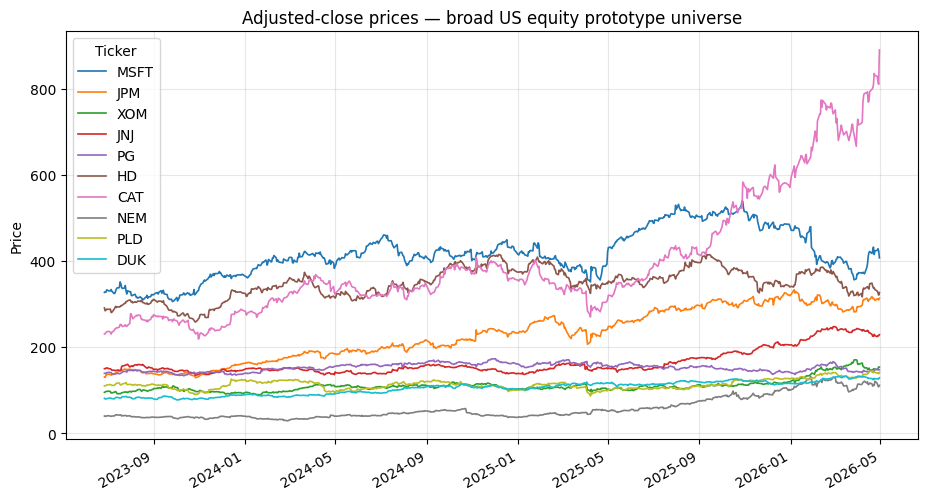

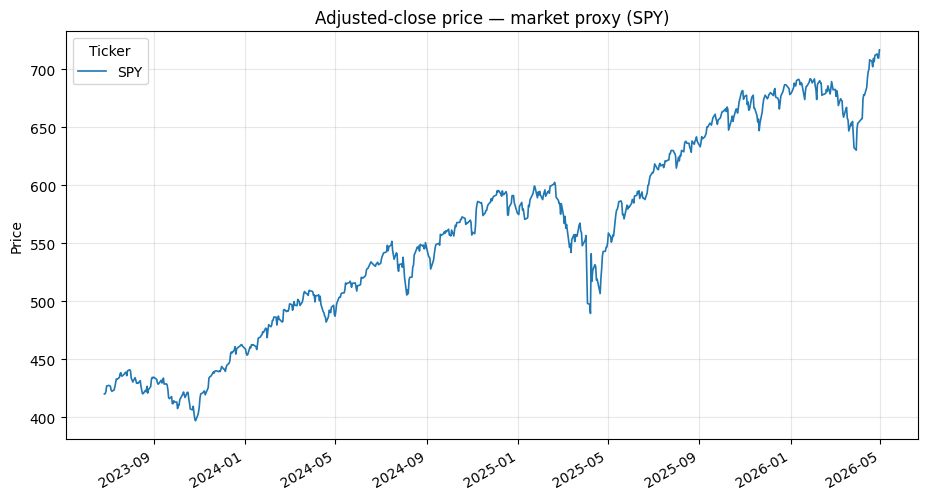

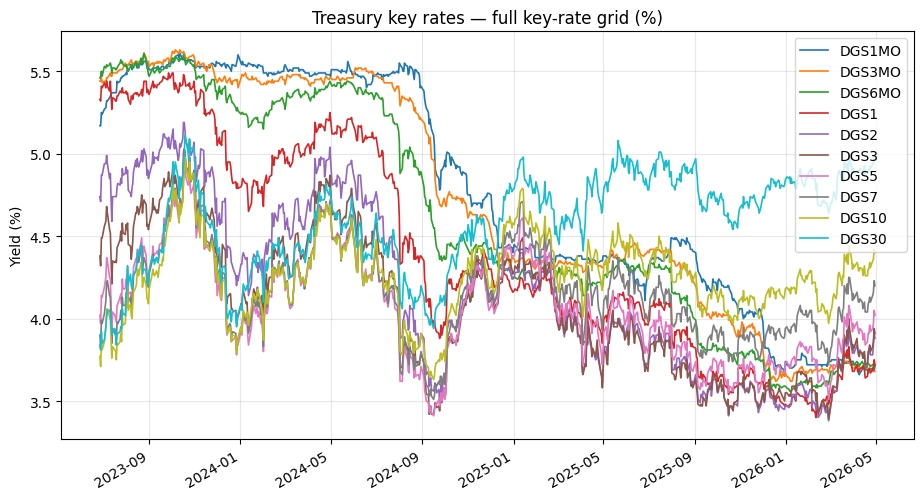

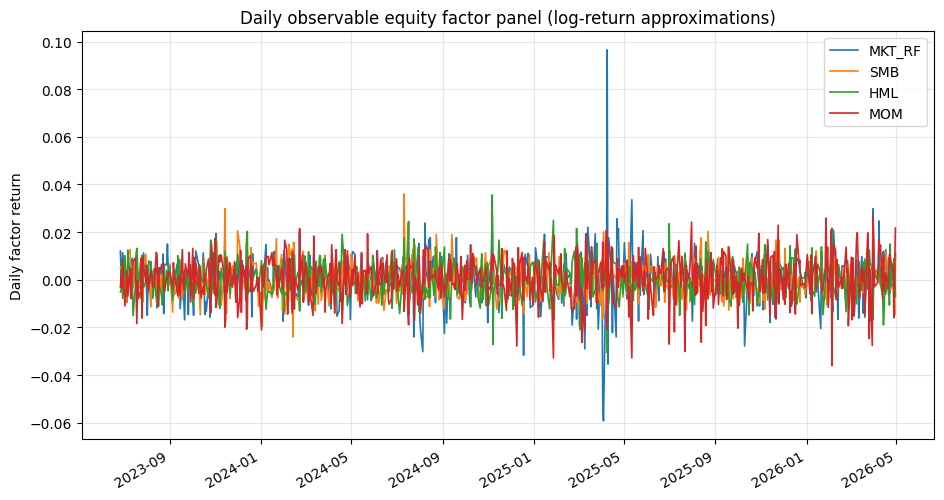

In [4]:
# Visual inspection of raw state variables
plot_time_series(stock_prices, "Adjusted-close prices — broad US equity prototype universe", "Price")
plot_time_series(market_proxy_prices, f"Adjusted-close price — market proxy ({MARKET_PROXY})", "Price")
plot_time_series(key_rates * 100.0, "Treasury key rates — full key-rate grid (%)", "Yield (%)")
plot_time_series(ff_factor_panel[[c for c in ["MKT_RF", "SMB", "HML", "MOM"] if c in ff_factor_panel.columns]],
                 "Daily observable equity factor panel (log-return approximations)",
                 "Daily factor return")


## 2. Risk-driver design and modular ERP engines

The equity block is plug-and-play. The notebook builds several alternative engines and lets the user choose the active one:

- **latent_statistical**: latent common factor extracted from equity excess returns;
- **proxy_market**: observed market ERP proxy via the broad market index;
- **apt_ff3**: observable factor engine based on MKT-RF, SMB, and HML;
- **apt_carhart**: observable factor engine based on MKT-RF, SMB, HML, and MOM.

Each engine is paired with a compressed idiosyncratic residual block.

Alongside equities, the engine builds factor blocks for the **Treasury curve**, **credit spreads**, and **FX**. The Treasury and credit blocks compress curve changes through PCA; the FX block uses currency-pair log returns. All blocks are stacked into a single joint state so equity/rates/credit/FX co-movements are preserved by the joint scenario generator.


In [5]:
# Build transformed risk drivers and alternative equity-premium engines
equity_log_returns = compute_equity_log_returns(stock_prices)
yield_changes = compute_yield_changes(key_rates)
market_log_returns = compute_equity_log_returns(market_proxy_prices)
spread_changes = compute_spread_changes(credit_spreads)
fx_log_returns = compute_fx_log_returns(fx_rates)

common_dates = (
    equity_log_returns.index
    .intersection(yield_changes.index)
    .intersection(market_log_returns.index)
    .intersection(ff_factor_panel.index)
    .intersection(spread_changes.index)
    .intersection(fx_log_returns.index)
)
equity_log_returns = equity_log_returns.loc[common_dates]
yield_changes = yield_changes.loc[common_dates]
spread_changes = spread_changes.loc[common_dates]
fx_log_returns = fx_log_returns.loc[common_dates]
key_rates = key_rates.loc[common_dates]
credit_spreads = credit_spreads.loc[common_dates]
fx_rates = fx_rates.loc[common_dates]
market_proxy_prices = market_proxy_prices.loc[common_dates]
ff_factor_panel = ff_factor_panel.loc[common_dates]

# single risk-free convention. The daily Fama-French RF (already downloaded) is the same
# risk-free that MKT_RF embeds, so we use it to define equity excess returns instead of DGS2/252.
rf_daily = ff_factor_panel["RF"]

latent_equity_block = build_latent_statistical_equity_block(
    log_returns=equity_log_returns,
    rf_daily=rf_daily,
    resid_explained_var_target=TARGET_RESID_EXPLAINED_VAR,
)

proxy_equity_block = build_proxy_market_equity_block(
    log_returns=equity_log_returns,
    market_proxy_prices=market_proxy_prices,
    rf_daily=rf_daily,
    resid_explained_var_target=TARGET_RESID_EXPLAINED_VAR,
)

apt_ff3_equity_block = build_apt_equity_block(
    log_returns=equity_log_returns,
    rf_daily=rf_daily,
    ff_factor_panel=ff_factor_panel,
    selected_factors=["MKT_RF", "SMB", "HML"],
    block_name="apt_ff3",
    resid_explained_var_target=TARGET_RESID_EXPLAINED_VAR,
)

apt_carhart_equity_block = build_apt_equity_block(
    log_returns=equity_log_returns,
    rf_daily=rf_daily,
    ff_factor_panel=ff_factor_panel,
    selected_factors=["MKT_RF", "SMB", "HML", "MOM"],
    block_name="apt_carhart",
    resid_explained_var_target=TARGET_RESID_EXPLAINED_VAR,
)

equity_engines = {
    "latent_statistical": latent_equity_block,
    "proxy_market": proxy_equity_block,
    "apt_ff3": apt_ff3_equity_block,
    "apt_carhart": apt_carhart_equity_block,
}

if ACTIVE_EQUITY_ENGINE not in equity_engines:
    raise ValueError(f"Unknown ACTIVE_EQUITY_ENGINE: {ACTIVE_EQUITY_ENGINE}")

equity_block = equity_engines[ACTIVE_EQUITY_ENGINE]

rates_block = build_rates_factor_model(
    yield_changes=yield_changes,
    explained_var_target=TARGET_RATE_EXPLAINED_VAR,
)

# Credit block: PCA of the rating-bucket OAS curve. Its factors join the joint state, so the
# equity-credit (Merton-type) co-movement is carried by the joint innovation bootstrap.
credit_block = build_credit_factor_model(
    spread_changes=spread_changes,
    explained_var_target=TARGET_CREDIT_EXPLAINED_VAR,
    max_factors=CREDIT_MAX_FACTORS,
)

# FX block: PCA of the currency-pair daily log-returns. Its factors join the joint state (after the
# credit PCs), so the equity-FX and rates-FX co-movements are carried by the same joint innovation
# bootstrap. With a single pair this is one factor; the block compresses if more pairs are added.
fx_block = build_fx_factor_block(
    fx_log_returns=fx_log_returns,
    explained_var_target=TARGET_FX_EXPLAINED_VAR,
    max_factors=FX_MAX_FACTORS,
)

# Crisis-tail calibration from the long Moody's Baa-Aaa history (decades incl. every postwar crisis).
# This characterizes how often / how severely credit blows out vs the short calm window; the regime
# overlay in the simulator uses it. Computed regardless of CRISIS_MODE (informative even when off).
crisis_calibration = compute_credit_crisis_calibration(
    moodys=moodys_raw,
    horizon_bdays=HORIZON_BDAYS,
    calm_sigma_threshold=CRISIS_SIGMA_THRESHOLD,
)
# Effective regime parameters: config overrides win, else the Moody's-calibrated values.
crisis_prob_eff = CRISIS_PROB if CRISIS_PROB is not None else crisis_calibration["crisis_prob"]
crisis_scale_eff = CRISIS_SCALE if CRISIS_SCALE is not None else crisis_calibration["crisis_scale"]
crisis_pool_eff = crisis_calibration["stress_magnitude_pool"]
print(
    f"Crisis backbone (Moody's Baa-Aaa, {crisis_calibration['history_start'].date()} -> "
    f"{crisis_calibration['history_end'].date()}, {crisis_calibration['n_total_days']} days): "
    f"{crisis_calibration['n_stress_days']} stress days -> crisis_prob={crisis_prob_eff:.4f}/day, "
    f"crisis_scale={crisis_scale_eff:.2f}x, tail dof={crisis_calibration['dof']:.1f}. "
    f"Active CRISIS_MODE={CRISIS_MODE!r}."
)

curve_lsc_levels = build_curve_lsc_factors(key_rates)
curve_lsc_changes = curve_lsc_levels.diff().dropna()

credit_lsc_levels = build_credit_lsc_factors(credit_spreads)
credit_lsc_changes = credit_lsc_levels.diff().dropna()

engine_summary = pd.concat([
    summarize_equity_engine(block) for block in equity_engines.values()
], axis=1).T.sort_values(["mean_asset_R2", "median_asset_R2"], ascending=False)

print(f"Active equity factor block: {equity_block['engine_name']}")
print(f"Rates factors retained   : {rates_block['n_factors']} (from {key_rates.shape[1]} tenors)")
print(f"Credit factors retained  : {credit_block['n_factors']} (from {credit_spreads.shape[1]} rating buckets)")
print(f"FX factors retained      : {fx_block['n_factors']} (from {fx_rates.shape[1]} currency pair(s))")
print(f"Daily risk-free source   : Fama-French RF (mean {rf_daily.mean():.6f}/day)")
print("Equity engine comparison:")
display(engine_summary)

print("Credit-spread PCA explained variance:")
display(credit_block["explained_ratio"].to_frame("credit_explained_variance_ratio"))

# Economic interpretation of the credit PCs via level / quality-slope / curvature changes
credit_interpretation = pd.concat([credit_block["scores"], credit_lsc_changes], axis=1).dropna().corr()
credit_interpretation = credit_interpretation.loc[credit_block["scores"].columns, credit_lsc_changes.columns]
print("Interpretation of credit PCA scores (corr with level / quality-slope / curvature changes):")
display(credit_interpretation)


Crisis backbone (Moody's Baa-Aaa, 1986-01-03 -> 2026-05-11, 10124 days): 271 stress days -> crisis_prob=0.0268/day, crisis_scale=7.28x, tail dof=4.1. Active CRISIS_MODE='none'.
Active equity factor block: apt_carhart
Rates factors retained   : 8 (from 10 tenors)
Credit factors retained  : 3 (from 7 rating buckets)
FX factors retained      : 1 (from 1 currency pair(s))
Daily risk-free source   : Fama-French RF (mean 0.000191/day)
Equity engine comparison:


,n_equity_factors,n_residual_factors,mean_asset_R2,median_asset_R2,max_asset_R2,min_asset_R2
apt_carhart,4.000000,9.000000,0.286981,0.290580,0.552846,0.081247
apt_ff3,3.000000,9.000000,0.267440,0.262471,0.545531,0.035117
latent_statistical,1.000000,8.000000,0.239116,0.182381,0.640419,0.044928
proxy_market,1.000000,9.000000,0.182308,0.165853,0.402238,0.000208


Credit-spread PCA explained variance:


,credit_explained_variance_ratio
credit_pc1,0.904440
credit_pc2,0.074819
credit_pc3,0.010109


Interpretation of credit PCA scores (corr with level / quality-slope / curvature changes):


,credit_level,credit_quality_slope,credit_curvature
credit_pc1,0.990802,0.963650,-0.943520
credit_pc2,-0.094398,0.253904,-0.295095
credit_pc3,0.095099,-0.063539,0.100002


Active engine beta matrix:


,MKT_RF,SMB,HML,MOM
asset,,,,
MSFT,0.922459,-0.335567,-0.546539,-0.032482
JPM,1.116910,-0.187289,0.925094,0.152709
XOM,0.546535,-0.256554,0.677341,-0.334283
JNJ,0.175866,-0.157607,0.313141,-0.238633
PG,0.247527,-0.289143,0.084567,-0.287966
HD,0.721172,0.317052,0.217025,-0.246663
CAT,1.192713,0.478871,0.620696,0.298030
NEM,0.633772,0.414105,0.250089,0.172256
PLD,0.924200,0.319216,0.425945,-0.342487


Active engine asset-level R^2:


,asset_R2
Ticker,
MSFT,0.484788
JPM,0.552846
XOM,0.223117
JNJ,0.095358
PG,0.081247
HD,0.358044
CAT,0.469418
NEM,0.090668
PLD,0.405723


Residual equity PCA explained variance (active engine):


...

,resid_cum_explained_ratio
resid_pc1,0.348582
resid_pc2,0.487326
resid_pc3,0.612105
resid_pc4,0.697777
resid_pc5,0.767134
resid_pc6,0.824879
resid_pc7,0.881015
resid_pc8,0.928506
resid_pc9,0.967256


Comparison across observable and latent equity factors:


,market_erp_proxy,latent_equity_factor,MKT_RF,MOM
market_erp_proxy,1.000000,0.649394,0.991171,0.160593
latent_equity_factor,0.649394,1.000000,0.653060,-0.014397
MKT_RF,0.991171,0.653060,1.000000,0.161103
MOM,0.160593,-0.014397,0.161103,1.000000


Economic interpretation of rates PCA scores via level / slope / curvature changes:


,curve_level,curve_slope,curve_curvature
rate_pc1,0.994753,0.740215,0.749632
rate_pc2,-0.044160,0.535882,-0.510285
rate_pc3,0.092992,-0.219099,-0.354747
rate_pc4,-0.008097,-0.324370,0.022861
rate_pc5,0.006301,-0.019101,0.138549
rate_pc6,0.002686,0.065593,-0.123185
rate_pc7,0.002202,0.001484,0.001977
rate_pc8,0.001930,0.074319,0.125270


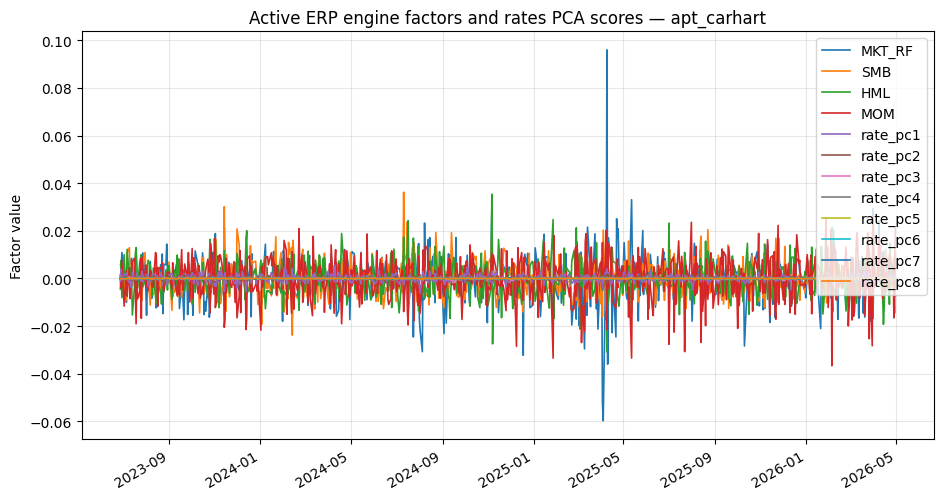

In [6]:

# Diagnostics on engine structure and factor interpretation
active_beta_table = equity_block["betas"].copy()
active_beta_table.index.name = "asset"

rate_interpretation = pd.concat([rates_block["scores"], curve_lsc_changes], axis=1).dropna().corr()
rate_interpretation = rate_interpretation.loc[rates_block["scores"].columns, curve_lsc_changes.columns]

compare_factor_table = pd.concat([
    proxy_equity_block["factors"].rename(columns={proxy_equity_block["factors"].columns[0]: "market_erp_proxy"}),
    latent_equity_block["factors"].rename(columns={latent_equity_block["factors"].columns[0]: "latent_equity_factor"}),
    ff_factor_panel[[c for c in ["MKT_RF", "MOM"] if c in ff_factor_panel.columns]],
], axis=1).dropna().corr()

print("Active engine beta matrix:")
display(active_beta_table)

print("Active engine asset-level R^2:")
display(equity_block["asset_r2"].to_frame("asset_R2"))

print("Residual equity PCA explained variance (active engine):")
display(equity_block["resid_explained_ratio"].to_frame("resid_explained_variance_ratio"))
display(equity_block["resid_cum_explained_ratio"].to_frame("resid_cum_explained_ratio"))

print("Comparison across observable and latent equity factors:")
display(compare_factor_table)

print("Economic interpretation of rates PCA scores via level / slope / curvature changes:")
display(rate_interpretation)

plot_time_series(
    pd.concat([equity_block["factors"], rates_block["scores"]], axis=1),
    f"Active ERP engine factors and rates PCA scores — {ACTIVE_EQUITY_ENGINE}",
    "Factor value",
)


## 3. Joint state representation and scenario engine

The active joint state vector stacks:

- selected **ERP engine factors**;
- compressed **equity residual factors**;
- compressed **Treasury curve factors**;
- compressed **credit-spread factors**;
- **FX factors**.

The default dynamics use a **joint stationary block-bootstrap** of demeaned state innovations. This avoids fitting a high-dimensional autoregressive model on a relatively short common equity/rates/credit/FX sample.

A **VAR(1)** model is still estimated for diagnostics and can be selected as an alternative dynamics mode. Its stability and one-step \(R^2\) are reported to assess whether autoregressive mean dynamics add useful predictive content.


In [7]:
# Joint state vector and dynamic model
drivers = build_joint_driver_matrix(equity_block, rates_block, credit_block, fx_block)
print(f"Joint driver matrix shape: {drivers.shape}")
print("Driver columns:")
print(drivers.columns.tolist())
display(drivers.head())

var_res = build_var1_model(drivers)
print("VAR(1) fitted successfully.")
print(f"Selected lag order: {var_res.k_ar}")
print(f"Number of state variables: {var_res.neqs}")
display(var_res.params)

try:
    print(var_res.summary())
except Exception as err:
    print("VAR summary could not be rendered cleanly.")
    print(f"Reason: {type(err).__name__}: {err}")

# stability check (statsmodels convention: stable iff ALL companion roots have modulus > 1)
print("Companion roots (modulus should be > 1 for stability):")
print(np.abs(var_res.roots))
print(f"VAR(1) is_stable(): {var_res.is_stable()}")
print(f"Min |root|: {np.min(np.abs(var_res.roots)):.4f}")

# is the VAR(1) doing real work, or is risk coming from the bootstrapped innovations?
# Per-equation one-step in-sample R^2 vs a constant-only baseline.
one_step_r2 = var_one_step_r2(var_res, drivers)
print()
print("VAR(1) one-step-ahead in-sample R^2 per driver:")
display(one_step_r2.to_frame("one_step_R2"))
print(
    f"Mean one-step R^2 across drivers: {one_step_r2.mean():.4f}. "
    "If these are near zero, the VAR mean dynamics add little predictive content and the simulated "
    "risk is effectively driven by the bootstrapped joint innovations + factor loadings; the model "
    "could then be simplified (block-bootstrap the demeaned innovations) or regularized."
)

# precompute the block-bootstrap innovation source (demeaned joint drivers + their mean),
# used by the simulator when DRIVER_DYNAMICS == "block_bootstrap". This drops the VAR(1) mean
# dynamics and resamples the demeaned drivers (equity factors + resid PCs + rate PCs + credit PCs +
# FX PCs) in stationary blocks around their mean.
driver_mean = drivers.mean()
demeaned_drivers = drivers - driver_mean

_k = drivers.shape[1]
_var_params = _k + _k * _k          # k intercepts + k*k AR coefficients
print()
print("Joint-state dynamics :")
_dyn_compare = pd.Series({
    "active_DRIVER_DYNAMICS": DRIVER_DYNAMICS,
    "state_dimension_k": _k,
    "var1_dynamics_parameters": _var_params,
    "block_bootstrap_dynamics_parameters": 0,
    "mean_one_step_R2": round(float(one_step_r2.mean()), 4),
})
display(_dyn_compare.to_frame("value"))
print(
    f"Active mode: {DRIVER_DYNAMICS}. 'block_bootstrap' resamples the demeaned joint innovations in "
    f"stationary blocks and removes the {_var_params} VAR(1) dynamics parameters; with a mean one-step "
    f"R^2 of {one_step_r2.mean():.4f} the VAR's mean dynamics contribute little, so the two modes give "
    "near-identical one-week distributions. Set DRIVER_DYNAMICS='var1' in the config to recover the "
    "VAR(1) engine and compare the tail metrics."
)


Joint driver matrix shape: (707, 25)
Driver columns:
['MKT_RF', 'SMB', 'HML', 'MOM', 'resid_pc1', 'resid_pc2', 'resid_pc3', 'resid_pc4', 'resid_pc5', 'resid_pc6', 'resid_pc7', 'resid_pc8', 'resid_pc9', 'rate_pc1', 'rate_pc2', 'rate_pc3', 'rate_pc4', 'rate_pc5', 'rate_pc6', 'rate_pc7', 'rate_pc8', 'credit_pc1', 'credit_pc2', 'credit_pc3', 'fx_pc1']


,MKT_RF,SMB,HML,MOM,resid_pc1,resid_pc2,resid_pc3,resid_pc4,resid_pc5,resid_pc6,...,rate_pc3,rate_pc4,rate_pc5,rate_pc6,rate_pc7,rate_pc8,credit_pc1,credit_pc2,credit_pc3,fx_pc1
2023-06-28,-0.000248,0.005714,-0.004553,0.001480,-0.034819,-0.009651,0.011208,0.012616,-0.002145,0.004880,...,0.000209,-0.000217,-0.000146,0.000100,0.000089,0.000001,-0.000479,-0.000034,0.000038,-0.005310
2023-06-29,0.003852,0.005514,0.007547,-0.004020,0.008721,-0.009667,0.002530,0.003084,-0.003335,0.015791,...,0.000427,0.000595,-0.000076,0.000069,-0.000054,0.000004,-0.002558,0.000442,-0.000121,-0.002207
2023-06-30,0.010852,-0.006186,-0.008053,0.007480,0.015421,0.016259,-0.002683,0.006121,-0.007434,0.000241,...,-0.000455,0.000333,-0.000024,-0.000091,-0.000064,-0.000102,-0.002151,-0.000670,0.000051,0.003482
2023-07-03,0.000952,0.000514,0.009947,-0.011620,0.004701,-0.008927,-0.004280,-0.006734,0.006120,0.004564,...,0.000292,0.000089,0.000031,-0.000118,0.000365,-0.000026,-0.001071,0.000217,0.000010,-0.000187
2023-07-05,-0.003448,-0.009386,-0.002753,-0.001520,-0.013510,0.011148,-0.003874,-0.003637,0.007442,-0.001337,...,0.000070,0.000213,0.000228,-0.000065,0.000077,-0.000101,0.000355,0.000038,-0.000194,-0.004777


VAR(1) fitted successfully.
Selected lag order: 1
Number of state variables: 25


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,MKT_RF,SMB,HML,MOM,resid_pc1,resid_pc2,resid_pc3,resid_pc4,resid_pc5,resid_pc6,...,rate_pc3,rate_pc4,rate_pc5,rate_pc6,rate_pc7,rate_pc8,credit_pc1,credit_pc2,credit_pc3,fx_pc1
const,-0.000008,-0.000008,0.000013,-0.000007,0.000055,0.000023,-0.000022,-0.000026,0.000004,-0.000012,...,-0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,0.000001,-0.000000,0.000000,0.000009
L1.MKT_RF,-0.118928,-0.071970,0.006546,0.058270,0.332260,0.058050,-0.106094,-0.220739,0.135868,-0.042830,...,0.001288,-0.000823,-0.000097,0.001894,-0.000277,0.001424,-0.020941,-0.002591,-0.003387,0.093346
L1.SMB,-0.048014,0.003213,0.082836,-0.012994,-0.148722,-0.232408,-0.064383,0.021370,0.021090,-0.063883,...,0.001840,-0.001044,-0.001156,-0.001186,-0.000566,-0.000900,-0.005541,0.000602,0.000792,-0.039369
L1.HML,0.090896,0.026803,0.056977,-0.058370,0.161873,0.087750,-0.061823,0.080202,-0.025517,0.040724,...,0.002144,-0.001323,-0.001473,0.000718,-0.000252,0.000893,-0.013131,0.000763,-0.000047,-0.019671
L1.MOM,0.053895,0.069372,0.068530,-0.096410,0.024317,-0.006736,-0.124386,-0.022622,-0.010920,0.011809,...,-0.000303,0.000286,-0.000638,-0.000742,-0.000241,0.000298,-0.000500,0.000326,0.002460,-0.023303
L1.resid_pc1,-0.000281,-0.005905,0.015003,-0.014837,-0.016058,0.053220,-0.025012,0.011601,0.011911,0.018826,...,-0.000340,0.000378,-0.000064,-0.000480,-0.000051,-0.000063,-0.001988,0.000355,-0.000162,0.002076
L1.resid_pc2,-0.030135,0.011729,0.009028,0.021803,-0.076914,-0.040737,-0.046408,-0.036436,0.008941,-0.003672,...,0.001494,0.000002,0.000005,0.000071,-0.000195,-0.000294,0.003200,0.000457,-0.000087,-0.014271
L1.resid_pc3,-0.007345,-0.006810,0.005538,-0.001850,0.068333,0.088771,0.061990,-0.045514,-0.008385,-0.016170,...,0.000187,-0.000426,-0.000214,0.000228,-0.000011,0.000165,-0.001488,-0.001070,0.000313,0.006104
L1.resid_pc4,0.040817,0.016567,0.002216,0.011738,-0.061262,0.013098,0.025654,-0.030945,-0.038550,-0.049859,...,-0.000570,-0.000013,0.000408,-0.000334,0.000028,0.000238,-0.004272,0.001359,-0.000755,-0.007241
L1.resid_pc5,0.025167,-0.048729,-0.036507,0.048110,0.030779,-0.093808,0.041574,-0.035377,-0.036014,0.026951,...,0.000526,-0.000387,0.000186,0.000050,0.000122,-0.000064,-0.005153,0.000717,-0.000228,-0.018894


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 27, Jun, 2026
Time:                     09:17:44
--------------------------------------------------------------------
No. of Equations:         25.0000    BIC:                   -306.538
Nobs:                     706.000    HQIC:                  -309.114
Log likelihood:           85295.7    FPE:               1.12011e-135
AIC:                     -310.736    Det(Omega_mle):    4.53527e-136
--------------------------------------------------------------------
Results for equation MKT_RF
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                -0.000008         0.000361           -0.022           0.983
L1.MKT_RF            -0.118928         0.055799           -2.131           0.033
L1.SMB               -0.048014         0.061043           -

,one_step_R2
credit_pc3,0.133019
credit_pc1,0.113569
rate_pc8,0.090078
rate_pc5,0.087002
MKT_RF,0.080929
resid_pc4,0.074793
rate_pc2,0.072365
fx_pc1,0.070554
credit_pc2,0.065493
rate_pc6,0.063161


Mean one-step R^2 across drivers: 0.0609. If these are near zero, the VAR mean dynamics add little predictive content and the simulated risk is effectively driven by the bootstrapped joint innovations + factor loadings; the model could then be simplified (block-bootstrap the demeaned innovations) or regularized.

Joint-state dynamics :


,value
active_DRIVER_DYNAMICS,block_bootstrap
state_dimension_k,25
var1_dynamics_parameters,650
block_bootstrap_dynamics_parameters,0
mean_one_step_R2,0.060900


Active mode: block_bootstrap. 'block_bootstrap' resamples the demeaned joint innovations in stationary blocks and removes the 650 VAR(1) dynamics parameters; with a mean one-step R^2 of 0.0609 the VAR's mean dynamics contribute little, so the two modes give near-identical one-week distributions. Set DRIVER_DYNAMICS='var1' in the config to recover the VAR(1) engine and compare the tail metrics.


In [8]:
# Simulate one-week joint scenarios under the active ERP engine
current_prices = stock_prices.loc[effective_date]
current_key_rates = key_rates.loc[effective_date]
current_spreads = credit_spreads.loc[effective_date]
current_fx = fx_rates.loc[effective_date]

# constant daily risk-free for the excess->total reconstruction, taken as the latest
# Fama-French RF (same convention used to define the excess returns). re-inject the
# idiosyncratic residual variance dropped by the PCA compression as iid noise. Credit block: the
# rating-bucket OAS curve is simulated jointly and returned as credit_spread_scenarios.
current_daily_rf = float(ff_factor_panel["RF"].iloc[-1])

sim = simulate_joint_horizon(
    var_res=var_res,
    resid_hist=var_res.resid,
    last_state=drivers.iloc[-1].to_numpy(),
    equity_block=equity_block,
    rates_block=rates_block,
    current_prices=current_prices,
    current_key_rates=current_key_rates,
    horizon_bdays=HORIZON_BDAYS,
    n_scenarios=N_SCENARIOS,
    avg_block_length=BOOTSTRAP_EXPECTED_BLOCK,
    rng_seed=RNG_SEED,
    daily_rf=current_daily_rf,
    resid_idio_std=equity_block.get("resid_idiosyncratic_std"),
    credit_block=credit_block,
    current_spreads=current_spreads,
    fx_block=fx_block,
    current_fx=current_fx,
    dynamics=DRIVER_DYNAMICS,
    demeaned_drivers=demeaned_drivers,
    driver_mean=driver_mean,
    crisis_mode=CRISIS_MODE,
    crisis_prob=crisis_prob_eff,
    crisis_scale=crisis_scale_eff,
    crisis_pool=crisis_pool_eff,
)

stock_excess_return_scenarios = sim["stock_excess_return_scenarios"]
stock_log_return_scenarios = sim["stock_log_return_scenarios"]
stock_price_scenarios = sim["stock_price_scenarios"]
key_rate_scenarios = sim["key_rate_scenarios"]
credit_spread_scenarios = sim["credit_spread_scenarios"]
fx_spot_scenarios = sim["fx_spot_scenarios"]


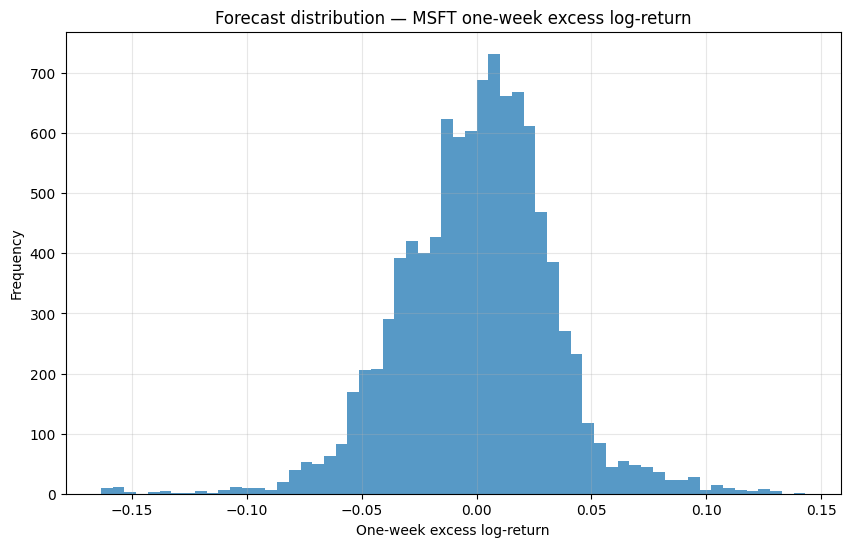

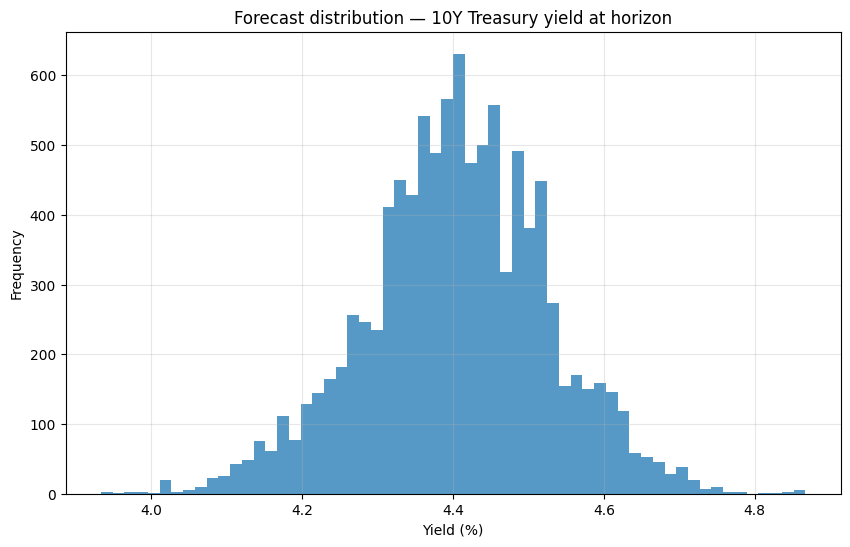

,MSFT_1w_excess_return
mean,0.000069
std,0.033152
q01,-0.081838
q05,-0.052885
median,0.002090
q95,0.048489
q99,0.088195
VaR_95_loss,0.052885
ES_95_loss,0.074039


,DGS10_horizon_yield
mean,0.044052
std,0.001218
q01,0.041121
q05,0.041937
median,0.044065
q95,0.046047
q99,0.046897
min,0.039333
max,0.048672


In [9]:

# Marginal forecast views
plot_histogram(
    stock_excess_return_scenarios[REPRESENTATIVE_EQUITY],
    f"Forecast distribution — {REPRESENTATIVE_EQUITY} one-week excess log-return",
    "One-week excess log-return",
)

plot_histogram(
    key_rate_scenarios["DGS10"] * 100.0,
    "Forecast distribution — 10Y Treasury yield at horizon",
    "Yield (%)",
)

display(loss_summary_from_pnl(stock_excess_return_scenarios[REPRESENTATIVE_EQUITY]).to_frame(f"{REPRESENTATIVE_EQUITY}_1w_excess_return"))
display(distribution_summary(key_rate_scenarios["DGS10"]).to_frame("DGS10_horizon_yield"))


Risk scaling (simulated one-week vs historical 5-day std):


,hist_5d_std,sim_1w_std,sim/hist
MSFT_return,0.032743,0.033152,1.012511
DGS10_change,0.001222,0.001218,0.997339


Tail behaviour (excess kurtosis, simulated vs historical 5-day):


,hist_5d_excess_kurtosis,sim_1w_excess_kurtosis
MSFT_return,1.968630,1.862414
DGS10_change,0.371006,0.324840


Cross-equity dependence (simulated vs historical 5-day):


...

,hist_5d_std,sim_1w_std,sim/hist
EURUSD,0.009583,0.009653,1.007238


Equity vs EURUSD 5-day-return correlation (simulated vs historical 5-day):


,sim,hist
MSFT,0.125451,0.147458
JPM,0.015707,0.040478
XOM,-0.120771,-0.127889
JNJ,0.136376,0.133680
PG,0.165470,0.173704
HD,0.185890,0.171532
CAT,0.095096,0.115058
NEM,0.364072,0.374379
PLD,0.164976,0.178767
DUK,0.182020,0.140502


Crisis-tail overlay effect on the equal-weight equity one-week loss (Moody's-calibrated: crisis_prob=0.0268/day, scale=7.28x):


,std,ES_95_loss,excess_kurtosis,worst_1pct,ES_uplift_vs_calm
none,0.018423,0.041637,3.290899,0.048196,1.000000
regime_jump,0.028146,0.068443,15.897022,0.092792,1.643817
moody_backbone,0.028985,0.061572,49.329235,0.077868,1.478800


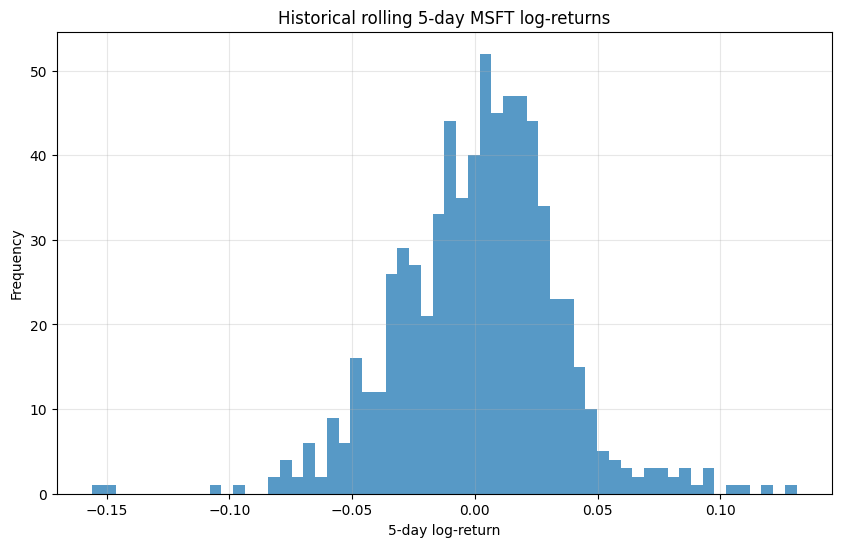

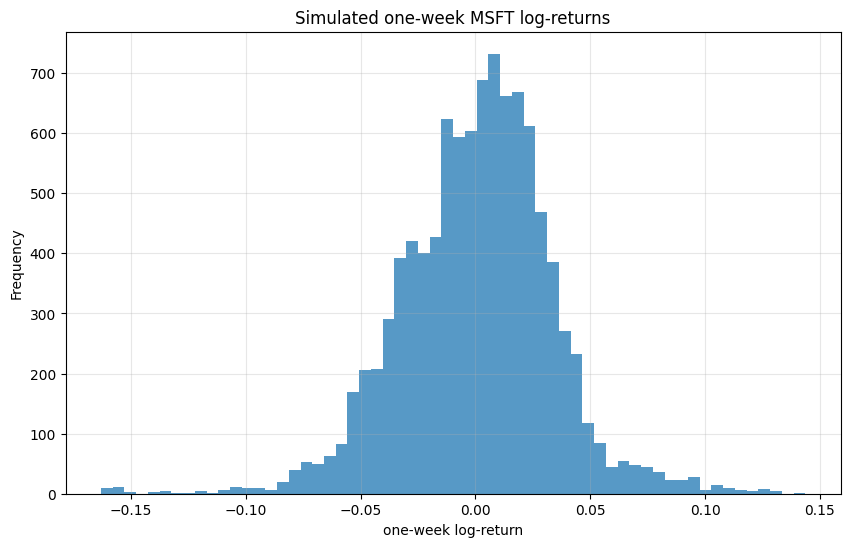

In [10]:
# Distributional and dependence validation (issues #1a, #1c; plus equity-credit dependence)
# A joint scenario engine must be judged on its dependence and tail calibration, not only on a
# single-name standard deviation. We compare simulated one-week behaviour with historical 5-day
# behaviour along seven dimensions (risk scaling, kurtosis, cross-equity correlation, equity-rates
# correlation, equity-credit correlation, credit-spread scaling, and FX risk-scaling / equity-FX
# correlation); the VaR coverage / PIT calibration is handled separately by the walk-forward
# backtest below.

hist_5d_stock = rolling_horizon_log_returns(equity_log_returns, HORIZON_BDAYS)
hist_5d_yield = rolling_horizon_yield_changes(yield_changes, HORIZON_BDAYS)
sim_d10 = key_rate_scenarios["DGS10"] - current_key_rates["DGS10"]

# (1) Risk scaling: simulated one-week std vs historical rolling 5-day std
scaling_table = pd.DataFrame({
    "hist_5d_std": [hist_5d_stock[REPRESENTATIVE_EQUITY].std(), hist_5d_yield["DGS10"].std()],
    "sim_1w_std": [stock_log_return_scenarios[REPRESENTATIVE_EQUITY].std(), sim_d10.std()],
}, index=[f"{REPRESENTATIVE_EQUITY}_return", "DGS10_change"])
scaling_table["sim/hist"] = scaling_table["sim_1w_std"] / scaling_table["hist_5d_std"]
print("Risk scaling (simulated one-week vs historical 5-day std):")
display(scaling_table)

# (2) Tail behaviour: excess kurtosis (pandas .kurt() is the Fisher / excess kurtosis)
def _exkurt(x):
    return float(pd.Series(x).kurt())

kurt_table = pd.DataFrame({
    "hist_5d_excess_kurtosis": [_exkurt(hist_5d_stock[REPRESENTATIVE_EQUITY]), _exkurt(hist_5d_yield["DGS10"])],
    "sim_1w_excess_kurtosis": [_exkurt(stock_log_return_scenarios[REPRESENTATIVE_EQUITY]), _exkurt(sim_d10)],
}, index=[f"{REPRESENTATIVE_EQUITY}_return", "DGS10_change"])
print("Tail behaviour (excess kurtosis, simulated vs historical 5-day):")
display(kurt_table)

# (3) Cross-equity dependence: simulated vs historical 5-day correlation matrices
sim_corr = stock_log_return_scenarios.corr()
hist_corr = hist_5d_stock.corr()

def _avg_offdiag(corr_df):
    arr = corr_df.to_numpy().copy()
    np.fill_diagonal(arr, np.nan)
    return float(np.nanmean(arr))

cross_equity_compare = pd.Series({
    "sim_avg_cross_equity_corr": _avg_offdiag(sim_corr),
    "hist_avg_cross_equity_corr": _avg_offdiag(hist_corr),
    "max_abs_pairwise_corr_diff": float(np.nanmax(np.abs(sim_corr.to_numpy() - hist_corr.to_numpy()))),
})
print("Cross-equity dependence (simulated vs historical 5-day):")
display(cross_equity_compare.to_frame("value"))

# (4) Equity-vs-rates dependence: corr(equity 5-day return, 5-day change in DGS10)
sim_eq_rate_corr = pd.Series(
    {t: float(np.corrcoef(stock_log_return_scenarios[t], sim_d10)[0, 1]) for t in TICKERS}
)
hist_joint = pd.concat([hist_5d_stock, hist_5d_yield["DGS10"].rename("DGS10_chg")], axis=1).dropna()
hist_eq_rate_corr = pd.Series({t: float(hist_joint[t].corr(hist_joint["DGS10_chg"])) for t in TICKERS})
eq_rate_compare = pd.DataFrame({"sim": sim_eq_rate_corr, "hist": hist_eq_rate_corr})
eq_rate_compare.loc["AVERAGE"] = eq_rate_compare.mean()
print("Equity vs DGS10-change correlation (simulated vs historical 5-day):")
display(eq_rate_compare)

# (5) Equity-credit dependence (the Merton-type link): corr(equity 5-day return, 5-day change in
# the representative-rating OAS). The joint innovation bootstrap should reproduce the empirical
# (negative) co-movement: when equity falls, credit spreads widen.
hist_5d_spread = rolling_horizon_yield_changes(spread_changes, HORIZON_BDAYS)
sim_dspread_rep = credit_spread_scenarios[REPRESENTATIVE_RATING] - current_spreads[REPRESENTATIVE_RATING]

sim_eq_credit_corr = pd.Series(
    {t: float(np.corrcoef(stock_log_return_scenarios[t], sim_dspread_rep)[0, 1]) for t in TICKERS}
)
hist_ec = pd.concat(
    [hist_5d_stock, hist_5d_spread[REPRESENTATIVE_RATING].rename("spread_chg")], axis=1
).dropna()
hist_eq_credit_corr = pd.Series({t: float(hist_ec[t].corr(hist_ec["spread_chg"])) for t in TICKERS})
eq_credit_compare = pd.DataFrame({"sim": sim_eq_credit_corr, "hist": hist_eq_credit_corr})
eq_credit_compare.loc["AVERAGE"] = eq_credit_compare.mean()
print(f"Equity vs {REPRESENTATIVE_RATING}-OAS-change correlation (simulated vs historical 5-day):")
display(eq_credit_compare)

# (6) Credit-spread risk scaling: simulated one-week vs historical 5-day std of the OAS change
credit_scaling = pd.DataFrame({
    "hist_5d_std": [hist_5d_spread[r].std() for r in credit_spread_scenarios.columns],
    "sim_1w_std": [(credit_spread_scenarios[r] - current_spreads[r]).std() for r in credit_spread_scenarios.columns],
}, index=list(credit_spread_scenarios.columns))
credit_scaling["sim/hist"] = credit_scaling["sim_1w_std"] / credit_scaling["hist_5d_std"]
print("Credit-spread risk scaling (simulated one-week vs historical 5-day std, by rating):")
display(credit_scaling)

# (7) FX block: simulated one-week vs historical 5-day std of the FX log-return, plus the equity-FX
# dependence (corr of the equity 5-day return with the 5-day FX log-return). Same sim-vs-hist logic
# as the other blocks; for a single pair this checks that the FX factor is scaled correctly and that
# its (weak) co-movement with equities is reproduced.
hist_5d_fx = rolling_horizon_log_returns(fx_log_returns, HORIZON_BDAYS)
sim_fx_ret = {p: np.log(fx_spot_scenarios[p] / current_fx[p]) for p in fx_spot_scenarios.columns}

fx_scaling = pd.DataFrame({
    "hist_5d_std": [hist_5d_fx[p].std() for p in fx_spot_scenarios.columns],
    "sim_1w_std": [sim_fx_ret[p].std() for p in fx_spot_scenarios.columns],
}, index=list(fx_spot_scenarios.columns))
fx_scaling["sim/hist"] = fx_scaling["sim_1w_std"] / fx_scaling["hist_5d_std"]
print("FX risk scaling (simulated one-week vs historical 5-day std of the FX log-return):")
display(fx_scaling)

rep_fx = list(fx_spot_scenarios.columns)[0]
sim_eq_fx_corr = pd.Series(
    {t: float(np.corrcoef(stock_log_return_scenarios[t], sim_fx_ret[rep_fx])[0, 1]) for t in TICKERS}
)
hist_ef = pd.concat([hist_5d_stock, hist_5d_fx[rep_fx].rename("fx_ret")], axis=1).dropna()
hist_eq_fx_corr = pd.Series({t: float(hist_ef[t].corr(hist_ef["fx_ret"])) for t in TICKERS})
eq_fx_compare = pd.DataFrame({"sim": sim_eq_fx_corr, "hist": hist_eq_fx_corr})
eq_fx_compare.loc["AVERAGE"] = eq_fx_compare.mean()
print(f"Equity vs {rep_fx} 5-day-return correlation (simulated vs historical 5-day):")
display(eq_fx_compare)

# (8) Crisis-tail overlay effect. The seven checks above validate the engine against the CALM
# 3-year sample. The crisis overlay is an opt-in stress layer that deliberately fattens the tail
# beyond that calm sample (the sample contains no real crisis). Here we quantify it: re-simulate the
# equal-weight equity one-week loss under the calm engine and under both crisis modes, calibrated
# from the long Moody's Baa-Aaa history, and compare the 95% ES and the excess kurtosis. This is a
# demonstration of the overlay, independent of the active CRISIS_MODE used elsewhere in the notebook.
def _eq_loss_tail(crisis_mode):
    s = simulate_joint_horizon(
        var_res=var_res, resid_hist=var_res.resid, last_state=drivers.iloc[-1].to_numpy(),
        equity_block=equity_block, rates_block=rates_block,
        current_prices=current_prices, current_key_rates=current_key_rates,
        horizon_bdays=HORIZON_BDAYS, n_scenarios=8000, avg_block_length=BOOTSTRAP_EXPECTED_BLOCK,
        rng_seed=RNG_SEED, daily_rf=current_daily_rf,
        resid_idio_std=equity_block.get("resid_idiosyncratic_std"),
        credit_block=credit_block, current_spreads=current_spreads,
        fx_block=fx_block, current_fx=current_fx,
        dynamics=DRIVER_DYNAMICS, demeaned_drivers=demeaned_drivers, driver_mean=driver_mean,
        crisis_mode=crisis_mode, crisis_prob=crisis_prob_eff, crisis_scale=crisis_scale_eff,
        crisis_pool=crisis_pool_eff,
    )
    port = s["stock_log_return_scenarios"].mean(axis=1)   # equal-weight equity one-week return
    loss = -port
    thr = loss.quantile(0.95)
    return {"std": float(port.std()), "ES_95_loss": float(loss[loss >= thr].mean()),
            "excess_kurtosis": float(port.kurtosis()),
            "worst_1pct": float(loss.quantile(0.99))}

crisis_compare = pd.DataFrame({m: _eq_loss_tail(m) for m in ["none", "regime_jump", "moody_backbone"]}).T
crisis_compare["ES_uplift_vs_calm"] = crisis_compare["ES_95_loss"] / crisis_compare.loc["none", "ES_95_loss"]
print(
    f"Crisis-tail overlay effect on the equal-weight equity one-week loss "
    f"(Moody's-calibrated: crisis_prob={crisis_prob_eff:.4f}/day, scale={crisis_scale_eff:.2f}x):"
)
display(crisis_compare)

# Marginal distribution shape, historical vs simulated
plot_histogram(
    hist_5d_stock[REPRESENTATIVE_EQUITY],
    f"Historical rolling 5-day {REPRESENTATIVE_EQUITY} log-returns",
    "5-day log-return",
)
plot_histogram(
    stock_log_return_scenarios[REPRESENTATIVE_EQUITY],
    f"Simulated one-week {REPRESENTATIVE_EQUITY} log-returns",
    "one-week log-return",
)


### 3b. Walk-forward VaR backtest

A single as-of date cannot validate a scenario engine. The notebook therefore refits the full pipeline on an expanding window across a panel of historical as-of dates.

At each date it simulates the one-week distribution of an equal-weight equity portfolio, takes the 95% VaR, and compares it with the realized forward one-week return. The diagnostics include:

- Kupiec proportion-of-failures test for unconditional coverage;
- Christoffersen independence test for breach clustering;
- PIT / rank histogram for calibration.

The defaults are deliberately modest because the cell refits the full engine repeatedly. They can be increased for stronger statistical power.


Walk-forward backtest: 40 as-of dates, 2000 scenarios each, equal-weight equity portfolio, 95% VaR.
From 2025-07-23 to 2026-05-01 (step 5 business days). This refits the engine at each date.



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  ...processed 10/40 as-of dates


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  ...processed 20/40 as-of dates


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  ...processed 40/40 as-of dates

Usable backtest observations: 40

VaR backtest (95%, equal-weight equity, one-week horizon):


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,value
observations,40.000000
violations,1.000000
expected_violations_at_5pct,2.000000
empirical_violation_rate,0.025000
kupiec_POF_LR,0.639794
kupiec_POF_pvalue,0.423786
christoffersen_indep_LR,0.052638
christoffersen_indep_pvalue,0.818536


Kupiec p-value tests unconditional coverage (H0: true violation rate = 5%); Christoffersen p-value tests independence (H0: no clustering of breaches). p-values above 0.05 do not reject a well-calibrated VaR.


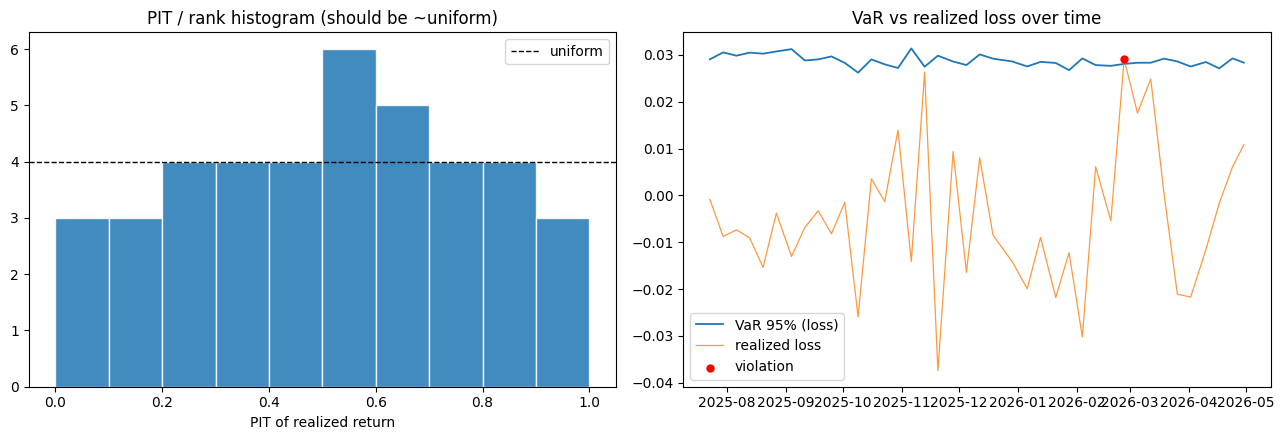

In [11]:
# Walk-forward VaR backtest with Kupiec (POF) and Christoffersen (independence) tests, plus a PIT
# histogram (issues #1b, #1d, #2). The engine is refit on an expanding window at each as-of date.

def _build_active_equity_block(log_returns, market_prices, ff_panel, rf_d):
    if ACTIVE_EQUITY_ENGINE == "latent_statistical":
        return build_latent_statistical_equity_block(log_returns, rf_d, TARGET_RESID_EXPLAINED_VAR)
    if ACTIVE_EQUITY_ENGINE == "proxy_market":
        return build_proxy_market_equity_block(log_returns, market_prices, rf_d, TARGET_RESID_EXPLAINED_VAR)
    if ACTIVE_EQUITY_ENGINE == "apt_ff3":
        return build_apt_equity_block(log_returns, rf_d, ff_panel, ["MKT_RF", "SMB", "HML"], "apt_ff3", TARGET_RESID_EXPLAINED_VAR)
    if ACTIVE_EQUITY_ENGINE == "apt_carhart":
        return build_apt_equity_block(log_returns, rf_d, ff_panel, ["MKT_RF", "SMB", "HML", "MOM"], "apt_carhart", TARGET_RESID_EXPLAINED_VAR)
    raise ValueError(f"Unknown ACTIVE_EQUITY_ENGINE: {ACTIVE_EQUITY_ENGINE}")


def _fit_engine_for_asof(asof):
    eff = choose_effective_asof(stock_prices_raw, market_proxy_raw, rates_raw, ff_factor_panel_raw, asof, credit=credit_spreads_raw)
    # FX is intentionally omitted from the refitted backtest engine: the backtest metric is
    # equal-weight EQUITY VaR coverage, which does not involve the FX forward, so adding the FX
    # factor here would only cost time. align now returns a 6-tuple; the FX slot is unused (None).
    sp, mp, kr, ff, cr, _fx = align_market_data(stock_prices_raw, market_proxy_raw, rates_raw, ff_factor_panel_raw, eff, credit=credit_spreads_raw)
    lr = compute_equity_log_returns(sp)
    dy = compute_yield_changes(kr)
    mlr = compute_equity_log_returns(mp)
    ds = compute_spread_changes(cr)
    cd = lr.index.intersection(dy.index).intersection(mlr.index).intersection(ff.index).intersection(ds.index)
    lr, dy, kr, mp, ff, ds, cr = lr.loc[cd], dy.loc[cd], kr.loc[cd], mp.loc[cd], ff.loc[cd], ds.loc[cd], cr.loc[cd]
    rf_d = ff["RF"]
    eb = _build_active_equity_block(lr, mp, ff, rf_d)
    rb = build_rates_factor_model(dy, TARGET_RATE_EXPLAINED_VAR)
    cb = build_credit_factor_model(ds, TARGET_CREDIT_EXPLAINED_VAR, max_factors=CREDIT_MAX_FACTORS)
    drv = build_joint_driver_matrix(eb, rb, cb)
    vr = build_var1_model(drv)
    return eff, sp, kr, cr, eb, rb, cb, drv, vr, float(rf_d.iloc[-1])


# Choose the panel of as-of dates from the trading calendar, ensuring a forward window exists.
_cal = stock_prices_raw.index
_elig = np.where(np.asarray(_cal <= AS_OF_DATE))[0]
_elig = _elig[_elig + HORIZON_BDAYS < len(_cal)]
_sel_positions = sorted(list(_elig[::-1][::BACKTEST_STEP_BDAYS][:BACKTEST_N_DATES]))
backtest_asof_dates = [_cal[p] for p in _sel_positions]

print(f"Walk-forward backtest: {len(backtest_asof_dates)} as-of dates, "
      f"{BACKTEST_N_SCENARIOS} scenarios each, equal-weight equity portfolio, 95% VaR.")
print(f"From {backtest_asof_dates[0].date()} to {backtest_asof_dates[-1].date()} "
      f"(step {BACKTEST_STEP_BDAYS} business days). This refits the engine at each date.\n")

bt_records = []
for j, asof in enumerate(backtest_asof_dates):
    try:
        eff, sp, kr, cr, eb, rb, cb, drv, vr, rf_last = _fit_engine_for_asof(asof)
        # honour DRIVER_DYNAMICS in the refitted backtest engine too, so the coverage test
        # reflects the same generative mechanism as the main engine. (FX is still omitted here: the
        # backtest metric is equal-weight EQUITY VaR, which does not involve the FX forward.)
        drv_mean = drv.mean()
        drv_demeaned = drv - drv_mean
        sim_bt = simulate_joint_horizon(
            var_res=vr, resid_hist=vr.resid, last_state=drv.iloc[-1].to_numpy(),
            equity_block=eb, rates_block=rb,
            current_prices=sp.loc[eff], current_key_rates=kr.loc[eff],
            horizon_bdays=HORIZON_BDAYS, n_scenarios=BACKTEST_N_SCENARIOS,
            avg_block_length=BOOTSTRAP_EXPECTED_BLOCK, rng_seed=RNG_SEED + j,
            daily_rf=rf_last, resid_idio_std=eb.get("resid_idiosyncratic_std"),
            credit_block=cb, current_spreads=cr.loc[eff],
            dynamics=DRIVER_DYNAMICS, demeaned_drivers=drv_demeaned, driver_mean=drv_mean,
            crisis_mode=CRISIS_MODE, crisis_prob=crisis_prob_eff, crisis_scale=crisis_scale_eff,
            crisis_pool=crisis_pool_eff,
        )
        # equal-weight equity portfolio one-week return = mean of single-name cumulative log returns
        port_sim = sim_bt["stock_log_return_scenarios"][TICKERS].mean(axis=1)
        var95 = float(-port_sim.quantile(0.05))

        eff_pos = stock_prices_raw.index.get_loc(eff)
        fwd_pos = eff_pos + HORIZON_BDAYS
        if fwd_pos >= len(stock_prices_raw.index):
            continue
        p0 = stock_prices_raw[TICKERS].iloc[eff_pos]
        p1 = stock_prices_raw[TICKERS].iloc[fwd_pos]
        realized = float(np.log(p1 / p0).mean())

        bt_records.append({
            "asof": eff,
            "VaR_95": var95,
            "realized_1w_return": realized,
            "violation": int(realized < -var95),
            "pit": float((port_sim <= realized).mean()),
        })
    except Exception as err:
        print(f"  [skip {pd.Timestamp(asof).date()}] {type(err).__name__}: {err}")
        continue

    if (j + 1) % 10 == 0:
        print(f"  ...processed {j + 1}/{len(backtest_asof_dates)} as-of dates")

bt = pd.DataFrame(bt_records)
print(f"\nUsable backtest observations: {len(bt)}")

if len(bt) >= 10:
    n_obs = len(bt)
    n_viol = int(bt["violation"].sum())
    expected = 0.05 * n_obs
    lr_k, p_k = kupiec_pof_test(n_viol, n_obs, 0.05)
    lr_c, p_c = christoffersen_independence_test(bt["violation"].to_numpy())

    summary = pd.Series({
        "observations": n_obs,
        "violations": n_viol,
        "expected_violations_at_5pct": expected,
        "empirical_violation_rate": n_viol / n_obs,
        "kupiec_POF_LR": lr_k,
        "kupiec_POF_pvalue": p_k,
        "christoffersen_indep_LR": lr_c,
        "christoffersen_indep_pvalue": p_c,
    }, name="walk_forward_VaR_backtest")
    print("\nVaR backtest (95%, equal-weight equity, one-week horizon):")
    display(summary.to_frame("value"))
    print(
        "Kupiec p-value tests unconditional coverage (H0: true violation rate = 5%); "
        "Christoffersen p-value tests independence (H0: no clustering of breaches). "
        "p-values above 0.05 do not reject a well-calibrated VaR."
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].hist(bt["pit"], bins=10, range=(0, 1), edgecolor="white", alpha=0.85)
    axes[0].axhline(len(bt) / 10.0, color="black", lw=1, ls="--", label="uniform")
    axes[0].set_title("PIT / rank histogram (should be ~uniform)")
    axes[0].set_xlabel("PIT of realized return")
    axes[0].legend()
    axes[1].plot(bt["asof"], bt["VaR_95"], label="VaR 95% (loss)", lw=1.3)
    axes[1].plot(bt["asof"], -bt["realized_1w_return"], label="realized loss", lw=0.9, alpha=0.8)
    viol = bt[bt["violation"] == 1]
    axes[1].scatter(viol["asof"], -viol["realized_1w_return"], color="red", s=25, zorder=5, label="violation")
    axes[1].set_title("VaR vs realized loss over time")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Too few usable observations for a meaningful backtest; increase BACKTEST_N_DATES "
          "or widen the data window.")


## 4. Horizon repricing

Simulated risk-driver states are mapped back into scenario-wise instrument values through:

- equity repricing from simulated cumulative log returns;
- Treasury note repricing from the simulated key-rate curve;
- corporate-bond repricing from the simulated Treasury curve plus rating-bucket OAS;
- FX-forward repricing from the simulated FX spot and carry convention.

The output is a panel of horizon values, P&L, and capital-normalized returns across instruments.


In [12]:
# Treasury note definition and current repricing
issue_date = pd.Timestamp(effective_date)
horizon_date = issue_date + BDay(HORIZON_BDAYS)
maturity_date = issue_date + pd.DateOffset(years=10)

coupon_schedule = generate_coupon_schedule(issue_date, maturity_date, freq=PAY_FREQ)

# the bond is priced off the full simulated curve. The tenor grid is taken from the
# active key-rate columns (ascending order), so the pricer is consistent with whatever tenors the
# rates block uses.
RATE_TENOR_YEARS = [TENOR_YEARS[t] for t in key_rates.columns]

current_bond_price = price_coupon_bond_from_curve(
    eval_date=issue_date,
    payment_dates=coupon_schedule,
    key_rate_series=current_key_rates,
    tenor_years=RATE_TENOR_YEARS,
    coupon_rate=COUPON_RATE,
    face_value=FACE_VALUE,
    freq=PAY_FREQ,
)

# clean/dirty decomposition. The DCF above returns the dirty (full) PV; accrued interest
# separates the clean price. At issue the note has just been struck, so accrued ~ 0.
accrued_at_issue = accrued_interest(issue_date, coupon_schedule, COUPON_RATE, FACE_VALUE, PAY_FREQ)
accrued_at_horizon = accrued_interest(horizon_date, coupon_schedule, COUPON_RATE, FACE_VALUE, PAY_FREQ)

print(f"Synthetic Treasury note dirty price at issue: {current_bond_price:,.4f}")
print(f"  accrued at issue: {accrued_at_issue:,.4f}  ->  clean: {current_bond_price - accrued_at_issue:,.4f}")
print(f"Issue date   : {issue_date.date()}")
print(f"Horizon date : {pd.Timestamp(horizon_date).date()}")
print(f"Maturity date: {maturity_date.date()}")
print(
    "Pricing convention (declared approximation): FRED CMT par yields are linearly interpolated "
    "across tenor and treated as continuously-compounded zero rates. Corporate bonds add a flat "
    "option-adjusted spread (OAS) for their rating bucket on top of that curve. P&L below is "
    "dirty-to-dirty; accrued interest is reported only for the clean/dirty split."
)

bond_horizon_prices = key_rate_scenarios.apply(
    lambda row: price_coupon_bond_from_curve(
        eval_date=horizon_date,
        payment_dates=coupon_schedule,
        key_rate_series=row,
        tenor_years=RATE_TENOR_YEARS,
        coupon_rate=COUPON_RATE,
        face_value=FACE_VALUE,
        freq=PAY_FREQ,
    ),
    axis=1,
)
bond_horizon_prices.name = "UST_10Y_2pct"
bond_pnl = bond_horizon_prices - current_bond_price

print(f"\nMean dirty PV at horizon: {bond_horizon_prices.mean():,.4f} "
      f"(accrued at horizon: {accrued_at_horizon:,.4f})")
display(distribution_summary(bond_horizon_prices).to_frame("UST_10Y_2pct_horizon_value"))
display(loss_summary_from_pnl(bond_pnl).to_frame("UST_10Y_2pct_one_week_pnl"))

# --- Corporate bonds: discount at the simulated Treasury curve + the simulated OAS for the rating.
# This is where the equity-credit link bites: scenarios with falling equities tend to carry widening
# spreads (joint bootstrap), so a corporate bond loses on both the rate and the credit channel.
corp_coupon_schedules = {}
corp_current_prices = {}
corp_horizon_prices = {}

print("\nCorporate bonds (priced on Treasury-zero + rating OAS):")
for spec in CORP_BONDS:
    name, rating = spec["name"], spec["rating"]
    cpn, mat_y = spec["coupon"], spec["maturity_years"]
    sched_c = generate_coupon_schedule(issue_date, issue_date + pd.DateOffset(years=mat_y), freq=PAY_FREQ)
    corp_coupon_schedules[name] = sched_c

    cur_spread = float(current_spreads[rating])
    corp_current_prices[name] = price_coupon_bond_from_curve(
        eval_date=issue_date, payment_dates=sched_c, key_rate_series=current_key_rates,
        tenor_years=RATE_TENOR_YEARS, coupon_rate=cpn, face_value=FACE_VALUE, freq=PAY_FREQ,
        spread=cur_spread,
    )
    corp_horizon_prices[name] = reprice_corporate_bond_scenarios(
        eval_date=horizon_date, payment_dates=sched_c, key_rate_scenarios=key_rate_scenarios,
        tenor_years=RATE_TENOR_YEARS, spread_scenarios=credit_spread_scenarios[rating],
        coupon_rate=cpn, face_value=FACE_VALUE, freq=PAY_FREQ,
    )
    pnl_c = corp_horizon_prices[name] - corp_current_prices[name]
    print(f"  {name} ({rating}, {cpn:.2%} {mat_y}Y): current OAS {cur_spread*1e4:,.0f}bps, "
          f"price {corp_current_prices[name]:,.3f} -> mean horizon {corp_horizon_prices[name].mean():,.3f} "
          f"(mean 1w P&L {pnl_c.mean():,.4f})")

# --- FX forward(s): a long-foreign forward struck at-the-money on the valuation curve, so its MTM
# is zero at inception and the one-week P&L is pure FX (the simulated spot) plus USD discounting (the
# simulated Treasury curve). It is repriced on the SAME simulated spot and curve rows, so an FX move
# and a rate move hit it jointly. For the capital-normalized portfolio layer the forward is treated
# as a fully-funded position: its capital base (current_value) is the USD notional and its horizon
# value is USD notional + MTM, so the instrument return is MTM / USD-notional.
fx_forward_specs = {}
fx_forward_current_values = {}
fx_forward_horizon_values = {}

print("\nFX forwards (long-foreign, struck at-the-money on the valuation curve):")
for spec in FX_FORWARDS:
    name, pair = spec["name"], spec["pair"]
    fwd_maturity = issue_date + pd.DateOffset(months=int(round(spec["maturity_years"] * 12)))
    spot0 = float(current_fx[pair])
    r_for = float(spec["foreign_funding_rate"])
    notl = float(spec["notional_foreign"])
    strike = atm_forward_fx_strike(
        eval_date=issue_date, maturity_date=fwd_maturity, spot=spot0,
        usd_key_rate_series=current_key_rates, usd_tenor_years=RATE_TENOR_YEARS,
        foreign_funding_rate=r_for,
    )
    usd_notional = notl * spot0
    mtm_h = reprice_fx_forward_scenarios(
        eval_date=horizon_date, maturity_date=fwd_maturity, spot_scenarios=fx_spot_scenarios[pair],
        usd_key_rate_scenarios=key_rate_scenarios, usd_tenor_years=RATE_TENOR_YEARS,
        strike=strike, foreign_funding_rate=r_for, notional_foreign=notl,
    )
    fx_forward_specs[name] = {
        "pair": pair, "maturity_date": fwd_maturity, "strike": strike,
        "foreign_funding_rate": r_for, "notional_foreign": notl, "usd_notional": usd_notional,
    }
    fx_forward_current_values[name] = usd_notional            # capital base (MTM at inception ~ 0)
    fx_forward_horizon_values[name] = usd_notional + mtm_h    # so return = MTM / USD-notional
    print(f"  {name} ({pair}, {spec['maturity_years']:.2f}Y): spot {spot0:.4f}, ATM strike {strike:.4f}, "
          f"USD notional {usd_notional:,.2f} -> mean horizon MTM {mtm_h.mean():,.4f} "
          f"(mean 1w return {(mtm_h.mean()/usd_notional):.4%})")

# Assemble the full instrument set: equities + Treasury + corporates + FX forward(s)
instrument_horizon_values = stock_price_scenarios.copy()
instrument_horizon_values["UST_10Y_2pct"] = bond_horizon_prices
for name in corp_horizon_prices:
    instrument_horizon_values[name] = corp_horizon_prices[name].to_numpy()
for name in fx_forward_horizon_values:
    instrument_horizon_values[name] = fx_forward_horizon_values[name].to_numpy()

current_values = current_prices.copy()
current_values["UST_10Y_2pct"] = current_bond_price
for name in corp_current_prices:
    current_values[name] = corp_current_prices[name]
for name in fx_forward_current_values:
    current_values[name] = fx_forward_current_values[name]

instrument_pnl = instrument_horizon_values.sub(current_values, axis=1)
instrument_returns = instrument_pnl.div(current_values, axis=1)

print("\nHorizon values:")
display(instrument_horizon_values.describe().T)

print("Instrument-level one-week P&L:")
display(instrument_pnl.describe().T)

print("Capital-normalized one-week return/loss metrics:")
display(pd.DataFrame({
    col: loss_summary_from_pnl(instrument_returns[col], alpha=CVAR_ALPHA)
    for col in instrument_returns.columns
}).T)


Synthetic Treasury note dirty price at issue: 80.5925
  accrued at issue: 0.0000  ->  clean: 80.5925
Issue date   : 2026-04-30
Horizon date : 2026-05-07
Maturity date: 2036-04-30
Pricing convention (declared approximation): FRED CMT par yields are linearly interpolated across tenor and treated as continuously-compounded zero rates. Corporate bonds add a flat option-adjusted spread (OAS) for their rating bucket on top of that curve. P&L below is dirty-to-dirty; accrued interest is reported only for the clean/dirty split.

Mean dirty PV at horizon: 80.6391 (accrued at horizon: 0.0383)


,UST_10Y_2pct_horizon_value
mean,80.639074
std,0.879489
q01,78.596845
q05,79.207323
median,80.621689
q95,82.178771
q99,82.830917
min,77.397065
max,84.154521


,UST_10Y_2pct_one_week_pnl
mean,0.046604
std,0.879489
q01,-1.995625
q05,-1.385148
median,0.029218
q95,1.586301
q99,2.238447
VaR_95_loss,1.385148
ES_95_loss,1.734936



Corporate bonds (priced on Treasury-zero + rating OAS):
  CORP_BBB_7Y (BBB, 5.20% 7Y): current OAS 102bps, price 99.675 -> mean horizon 99.798 (mean 1w P&L 0.1235)
  CORP_BB_5Y (BB, 6.80% 5Y): current OAS 174bps, price 104.166 -> mean horizon 104.317 (mean 1w P&L 0.1510)

FX forwards (long-foreign, struck at-the-money on the valuation curve):
  FXFWD_EURUSD_3M (EURUSD, 0.25Y): spot 1.1729, ATM strike 1.1778, USD notional 117.29 -> mean horizon MTM 0.0304 (mean 1w return 0.0259%)

Horizon values:


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
MSFT,"10,000.000000",407.353646,13.465761,345.654702,398.945049,407.953915,415.581360,469.776207
JPM,"10,000.000000",315.149334,10.221612,267.075087,309.371003,315.876286,321.418174,362.524677
XOM,"10,000.000000",153.768635,4.877203,128.225412,150.486195,153.908143,157.125413,170.985828
JNJ,"10,000.000000",229.169453,5.599748,205.258216,225.546012,229.098067,232.847986,252.420420
PG,"10,000.000000",147.140656,3.379771,130.894084,144.901997,147.185871,149.333654,159.503659
HD,"10,000.000000",326.525357,10.316332,283.746410,319.853500,326.530197,333.204574,375.126375
CAT,"10,000.000000",899.001971,38.109047,711.427658,873.821759,897.412118,922.597262,"1,053.922202"
NEM,"10,000.000000",111.782413,6.307911,79.512381,108.049420,111.867931,115.817599,139.853157
PLD,"10,000.000000",141.255442,5.080319,112.944650,138.552319,141.425890,144.177907,166.366202


Instrument-level one-week P&L:


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
MSFT,"10,000.000000",0.454933,13.465761,-61.244010,-7.953664,1.055203,8.682648,62.877495
JPM,"10,000.000000",1.919323,10.221612,-46.154924,-3.859008,2.646275,8.188163,49.294666
XOM,"10,000.000000",0.479084,4.877203,-25.064139,-2.803355,0.618592,3.835863,17.696277
JNJ,"10,000.000000",0.633763,5.599748,-23.277475,-2.989678,0.562377,4.312296,23.884730
PG,"10,000.000000",0.050659,3.379771,-16.195913,-2.187999,0.095874,2.243657,12.413663
HD,"10,000.000000",0.173215,10.316332,-42.605732,-6.498643,0.178055,6.852432,48.774233
CAT,"10,000.000000",8.891986,38.109047,-178.682328,-16.288226,7.302133,32.487277,163.812216
NEM,"10,000.000000",0.951206,6.307911,-31.318827,-2.781788,1.036724,4.986392,29.021949
PLD,"10,000.000000",0.258737,5.080319,-28.052054,-2.444385,0.429186,3.181203,25.369498


Capital-normalized one-week return/loss metrics:


,mean,std,q01,q05,median,q95,q99,VaR_95_loss,ES_95_loss
MSFT,0.001118,0.033094,-0.078118,-0.051037,0.002593,0.050208,0.092747,0.051037,0.070612
JPM,0.006128,0.032633,-0.085506,-0.050163,0.008448,0.054676,0.078149,0.050163,0.074624
XOM,0.003125,0.031817,-0.088455,-0.046271,0.004035,0.050588,0.070770,0.046271,0.068366
JNJ,0.002773,0.024503,-0.054616,-0.035887,0.002461,0.042134,0.065109,0.035887,0.047545
PG,0.000344,0.022978,-0.054572,-0.037353,0.000652,0.037747,0.054736,0.037353,0.047948
HD,0.000531,0.031611,-0.073843,-0.051198,0.000546,0.052007,0.075006,0.051198,0.066336
CAT,0.009990,0.042814,-0.089887,-0.054882,0.008204,0.085766,0.117964,0.054882,0.080584
NEM,0.008582,0.056915,-0.131785,-0.088615,0.009354,0.097833,0.137797,0.088615,0.117771
PLD,0.001835,0.036031,-0.101769,-0.056948,0.003044,0.056785,0.095033,0.056948,0.085533
DUK,0.003354,0.024473,-0.054428,-0.036929,0.003493,0.043975,0.059573,0.036929,0.047215


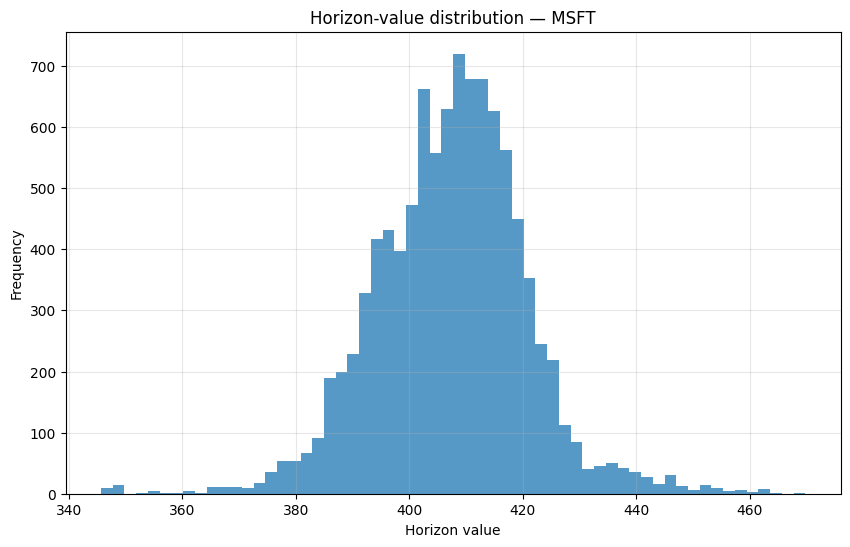

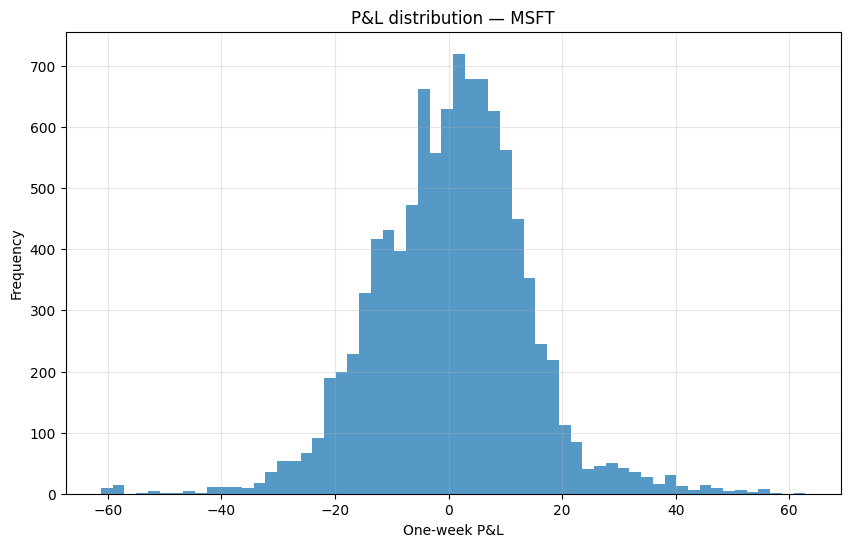

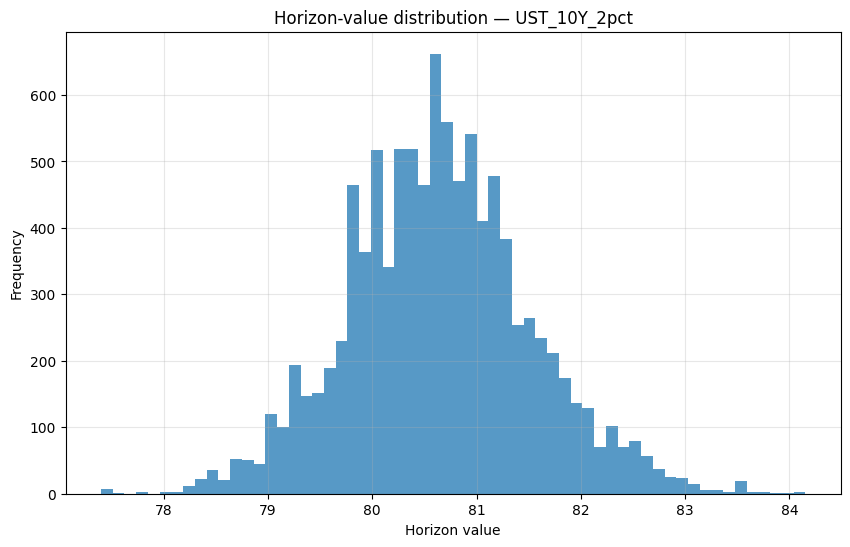

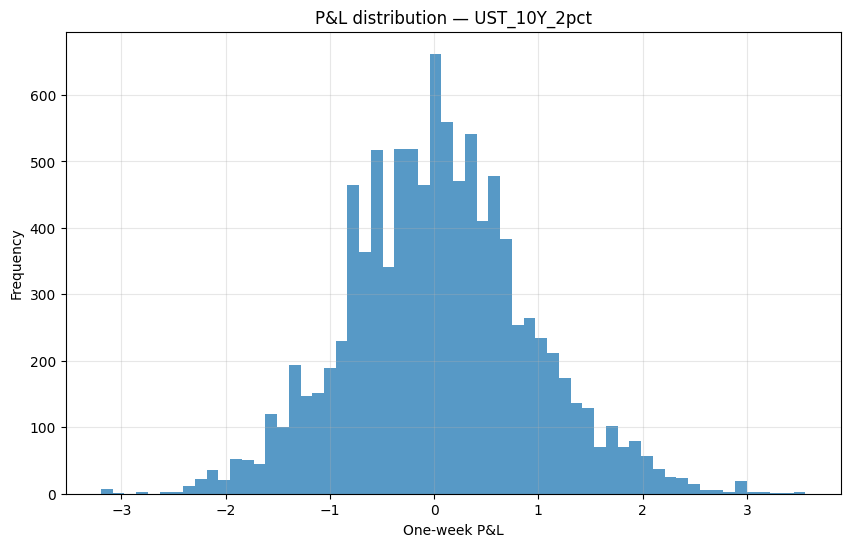

In [13]:

# Selected instrument-level visualizations
plot_histogram(instrument_horizon_values[REPRESENTATIVE_EQUITY], f"Horizon-value distribution — {REPRESENTATIVE_EQUITY}", "Horizon value")
plot_histogram(instrument_pnl[REPRESENTATIVE_EQUITY], f"P&L distribution — {REPRESENTATIVE_EQUITY}", "One-week P&L")
plot_histogram(instrument_horizon_values["UST_10Y_2pct"], "Horizon-value distribution — UST_10Y_2pct", "Horizon value")
plot_histogram(instrument_pnl["UST_10Y_2pct"], "P&L distribution — UST_10Y_2pct", "One-week P&L")


## 5. Portfolio layer under capital-normalized scenario returns

Portfolio comparisons are performed on **one-week simple returns**, not raw dollar P&L per instrument unit. This keeps tail-risk comparisons economically interpretable when assets have different nominal prices.

The portfolio layer includes:

- equal-weight and benchmark allocations;
- inverse-volatility allocation;
- long-only minimum-CVaR optimisation via linear programming;
- VaR and Expected Shortfall summaries;
- weighted tail-contribution diagnostics;
- a fresh-draw scenario check for optimisation stability.


In [14]:
# Candidate portfolio weights in capital-normalized return space
all_assets = instrument_returns.columns.tolist()
equity_assets = TICKERS.copy()
corp_assets = [spec["name"] for spec in CORP_BONDS]
fx_assets = [spec["name"] for spec in FX_FORWARDS]

equal_weight = pd.Series(1.0 / len(all_assets), index=all_assets)

equity_only = pd.Series(0.0, index=all_assets)
equity_only.loc[equity_assets] = 1.0 / len(equity_assets)

# Treasury-heavy: 60% Treasury, 40% spread across equities, no corporate credit (sums to 1 over the
# enlarged universe — the previous fixed-denominator version no longer summed to one once corporate
# bonds were added).
bond_heavy = pd.Series(0.0, index=all_assets)
bond_heavy.loc[equity_assets] = 0.40 / len(equity_assets)
bond_heavy["UST_10Y_2pct"] = 0.60

# Credit-tilt: deliberately loads the corporate (credit-spread) names to expose the new risk block.
credit_tilt = pd.Series(0.0, index=all_assets)
credit_tilt.loc[equity_assets] = 0.40 / len(equity_assets)
credit_tilt["UST_10Y_2pct"] = 0.20
if corp_assets:
    for c in corp_assets:
        credit_tilt[c] = 0.40 / len(corp_assets)

# FX-overlay: equities + Treasury with a sleeve allocated to the FX forward(s), to exercise the FX
# block in the portfolio. The forward's capital base is its USD notional, so a weight here is the
# fraction of capital carried as the (fully-funded) FX position. Sums to one over the universe.
fx_overlay = pd.Series(0.0, index=all_assets)
fx_overlay.loc[equity_assets] = 0.40 / len(equity_assets)
fx_overlay["UST_10Y_2pct"] = 0.40
if fx_assets:
    for f in fx_assets:
        fx_overlay[f] = 0.20 / len(fx_assets)

inverse_vol = inverse_vol_weights_from_scenarios(instrument_returns)

# exact long-only min-CVaR via the Rockafellar-Uryasev LP.
min_cvar_long_only, min_cvar_info = search_long_only_min_cvar_portfolio(
    instrument_returns=instrument_returns,
    alpha=CVAR_ALPHA,
    max_weight=CVAR_MAX_WEIGHT,
)

portfolio_weights = {
    "equal_weight": equal_weight,
    "equity_only": equity_only,
    "bond_heavy": bond_heavy,
    "credit_tilt": credit_tilt,
    "fx_overlay": fx_overlay,
    "inverse_vol": inverse_vol,
    "min_cvar_long_only": min_cvar_long_only,
}

portfolio_returns = {}
portfolio_metrics = {}
for name, w in portfolio_weights.items():
    port_ret, metrics = portfolio_metrics_from_instrument_returns(w, instrument_returns, alpha=CVAR_ALPHA)
    portfolio_returns[name] = port_ret
    portfolio_metrics[name] = metrics

print("Long-only min-CVaR LP diagnostics:")
display(min_cvar_info.to_frame("value"))

print("Portfolio weights:")
display(pd.DataFrame(portfolio_weights).T)

print("Portfolio one-week return/loss metrics:")
display(pd.DataFrame(portfolio_metrics).T.sort_values("ES_95_loss"))


Long-only min-CVaR LP diagnostics:


,value
n_scenarios,"10,000.000000"
VaR_95_loss,0.009984
ES_95_loss,0.012680
mean,0.000974
std,0.006638


Portfolio weights:


,MSFT,JPM,XOM,JNJ,PG,HD,CAT,NEM,PLD,DUK,UST_10Y_2pct,CORP_BBB_7Y,CORP_BB_5Y,FXFWD_EURUSD_3M
equal_weight,0.071429,0.071429,0.071429,0.071429,0.071429,0.071429,0.071429,0.071429,0.071429,0.071429,0.071429,0.071429,0.071429,0.071429
equity_only,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000
bond_heavy,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.600000,0.000000,0.000000,0.000000
credit_tilt,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.200000,0.200000,0.200000,0.000000
fx_overlay,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.400000,0.000000,0.000000,0.200000
inverse_vol,0.039004,0.039554,0.040569,0.052679,0.056175,0.040833,0.030148,0.022679,0.035823,0.052743,0.118280,0.171690,0.165658,0.134165
min_cvar_long_only,0.005451,0.002253,0.037022,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.454371,0.122103,0.378800


Portfolio one-week return/loss metrics:


,mean,std,q01,q05,median,q95,q99,VaR_95_loss,ES_95_loss,mean_abs_weight
min_cvar_long_only,0.000974,0.006638,-0.013422,-0.009984,0.001013,0.011537,0.019302,0.009984,0.012680,0.071429
inverse_vol,0.001894,0.009976,-0.025445,-0.014455,0.002427,0.016719,0.027024,0.014455,0.021291,0.071429
fx_overlay,0.001794,0.010654,-0.026287,-0.015803,0.002195,0.018176,0.028900,0.015803,0.021913,0.071429
credit_tilt,0.002165,0.010791,-0.028773,-0.015838,0.002740,0.017929,0.029347,0.015838,0.023063,0.071429
bond_heavy,0.001858,0.011433,-0.027881,-0.017353,0.002417,0.019393,0.030046,0.017353,0.023744,0.071429
equal_weight,0.002950,0.014554,-0.038820,-0.021292,0.003753,0.024240,0.037992,0.021292,0.031890,0.071429
equity_only,0.003778,0.018735,-0.047993,-0.028153,0.005110,0.030763,0.047174,0.028153,0.041499,0.071429


In [15]:
# Out-of-sample (fresh-draw) portfolio tail risk (implementation note)
# The min-CVaR weights are chosen to minimize ES on the in-sample scenario set, so the in-sample
# ES is optimistically biased (selection on noise). We simulate an INDEPENDENT scenario set with a
# different seed, reprice every instrument (equities, Treasury, corporates, FX forward), and
# re-evaluate the SAME weights to get an honest ES.

sim_oos = simulate_joint_horizon(
    var_res=var_res,
    resid_hist=var_res.resid,
    last_state=drivers.iloc[-1].to_numpy(),
    equity_block=equity_block,
    rates_block=rates_block,
    current_prices=current_prices,
    current_key_rates=current_key_rates,
    horizon_bdays=HORIZON_BDAYS,
    n_scenarios=N_SCENARIOS,
    avg_block_length=BOOTSTRAP_EXPECTED_BLOCK,
    rng_seed=VALIDATION_SEED,
    daily_rf=current_daily_rf,
    resid_idio_std=equity_block.get("resid_idiosyncratic_std"),
    credit_block=credit_block,
    current_spreads=current_spreads,
    fx_block=fx_block,
    current_fx=current_fx,
    dynamics=DRIVER_DYNAMICS,
    demeaned_drivers=demeaned_drivers,
    driver_mean=driver_mean,
    crisis_mode=CRISIS_MODE,
    crisis_prob=crisis_prob_eff,
    crisis_scale=crisis_scale_eff,
    crisis_pool=crisis_pool_eff,
)

key_rate_scenarios_oos = sim_oos["key_rate_scenarios"]
credit_spread_scenarios_oos = sim_oos["credit_spread_scenarios"]
fx_spot_scenarios_oos = sim_oos["fx_spot_scenarios"]

bond_horizon_prices_oos = key_rate_scenarios_oos.apply(
    lambda row: price_coupon_bond_from_curve(
        eval_date=horizon_date,
        payment_dates=coupon_schedule,
        key_rate_series=row,
        tenor_years=RATE_TENOR_YEARS,
        coupon_rate=COUPON_RATE,
        face_value=FACE_VALUE,
        freq=PAY_FREQ,
    ),
    axis=1,
)

instrument_horizon_values_oos = sim_oos["stock_price_scenarios"].copy()
instrument_horizon_values_oos["UST_10Y_2pct"] = bond_horizon_prices_oos
for spec in CORP_BONDS:
    name, rating = spec["name"], spec["rating"]
    instrument_horizon_values_oos[name] = reprice_corporate_bond_scenarios(
        eval_date=horizon_date, payment_dates=corp_coupon_schedules[name],
        key_rate_scenarios=key_rate_scenarios_oos, tenor_years=RATE_TENOR_YEARS,
        spread_scenarios=credit_spread_scenarios_oos[rating],
        coupon_rate=spec["coupon"], face_value=FACE_VALUE, freq=PAY_FREQ,
    ).to_numpy()

# FX forward(s) on the independent draw: same struck strike / maturity / notional as the in-sample
# leg (from fx_forward_specs), repriced on the fresh spot and curve, then expressed as USD notional
# + MTM so it matches the fully-funded current_value used in-sample.
for name, fwd in fx_forward_specs.items():
    mtm_oos = reprice_fx_forward_scenarios(
        eval_date=horizon_date, maturity_date=fwd["maturity_date"],
        spot_scenarios=fx_spot_scenarios_oos[fwd["pair"]], usd_key_rate_scenarios=key_rate_scenarios_oos,
        usd_tenor_years=RATE_TENOR_YEARS, strike=fwd["strike"],
        foreign_funding_rate=fwd["foreign_funding_rate"], notional_foreign=fwd["notional_foreign"],
    )
    instrument_horizon_values_oos[name] = (fwd["usd_notional"] + mtm_oos).to_numpy()

instrument_returns_oos = instrument_horizon_values_oos.sub(current_values, axis=1).div(current_values, axis=1)

oos_rows = {}
for name, w in portfolio_weights.items():
    _, m_in = portfolio_metrics_from_instrument_returns(w, instrument_returns, alpha=CVAR_ALPHA)
    _, m_oos = portfolio_metrics_from_instrument_returns(w, instrument_returns_oos, alpha=CVAR_ALPHA)
    oos_rows[name] = {
        "VaR_95_in_sample": m_in["VaR_95_loss"],
        "VaR_95_out_of_sample": m_oos["VaR_95_loss"],
        "ES_95_in_sample": m_in["ES_95_loss"],
        "ES_95_out_of_sample": m_oos["ES_95_loss"],
    }

oos_table = pd.DataFrame(oos_rows).T
oos_table["ES_in_sample_optimism"] = oos_table["ES_95_out_of_sample"] - oos_table["ES_95_in_sample"]
print("In-sample vs out-of-sample one-week tail risk (independent scenario draw):")
display(oos_table.sort_values("ES_95_out_of_sample"))
print(
    "A positive 'ES_in_sample_optimism' for min_cvar_long_only is the selection-on-noise effect: "
    "the weights were fit to the in-sample tail, so their ES degrades out-of-sample. Policy "
    "portfolios (equal_weight, equity_only, bond_heavy, credit_tilt, fx_overlay) are not fit to the "
    "scenarios and should show only sampling noise between the two columns."
)


In-sample vs out-of-sample one-week tail risk (independent scenario draw):


,VaR_95_in_sample,VaR_95_out_of_sample,ES_95_in_sample,ES_95_out_of_sample,ES_in_sample_optimism
min_cvar_long_only,0.009984,0.009748,0.012680,0.012362,-0.000318
inverse_vol,0.014455,0.014003,0.021291,0.020139,-0.001153
fx_overlay,0.015803,0.015647,0.021913,0.021066,-0.000847
credit_tilt,0.015838,0.015540,0.023063,0.021757,-0.001306
bond_heavy,0.017353,0.017070,0.023744,0.022790,-0.000954
equal_weight,0.021292,0.020609,0.031890,0.029896,-0.001993
equity_only,0.028153,0.027126,0.041499,0.038940,-0.002558


A positive 'ES_in_sample_optimism' for min_cvar_long_only is the selection-on-noise effect: the weights were fit to the in-sample tail, so their ES degrades out-of-sample. Policy portfolios (equal_weight, equity_only, bond_heavy, credit_tilt, fx_overlay) are not fit to the scenarios and should show only sampling noise between the two columns.


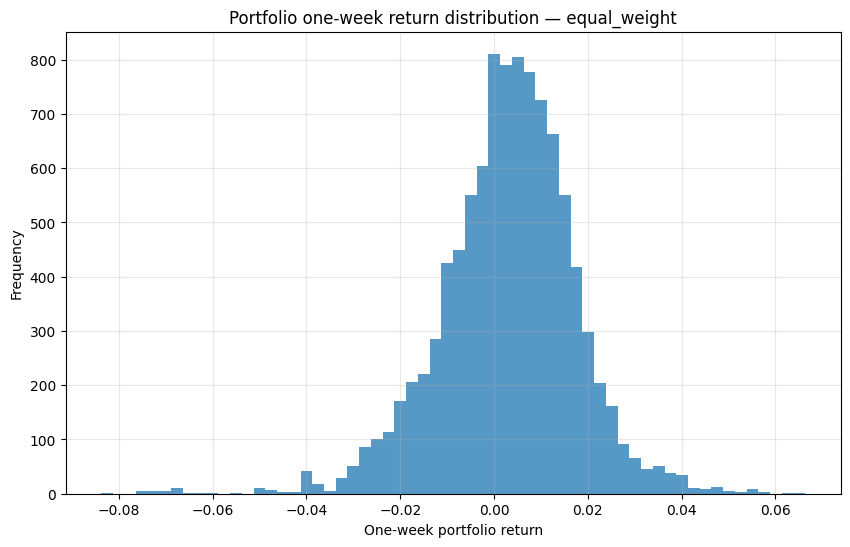

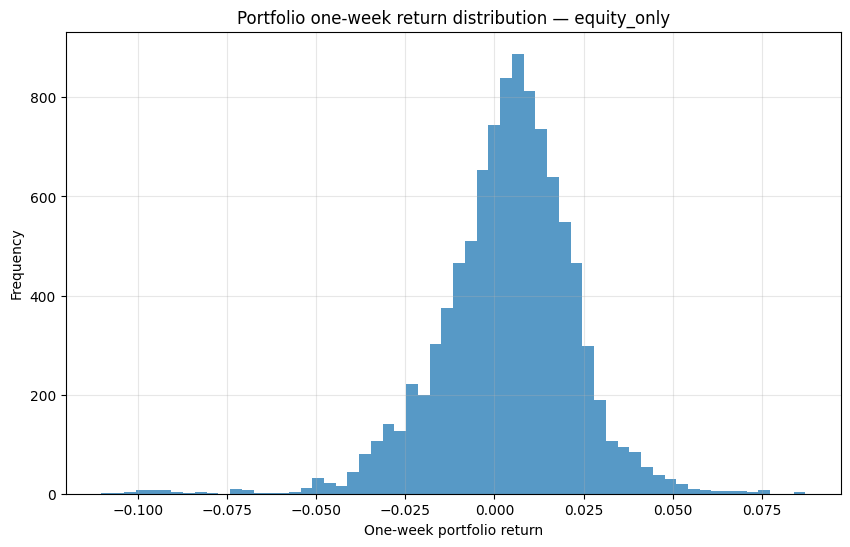

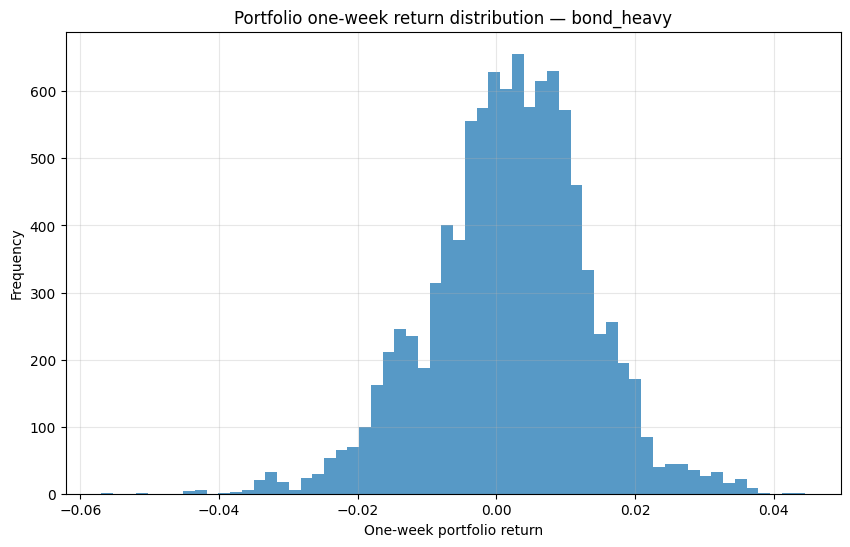

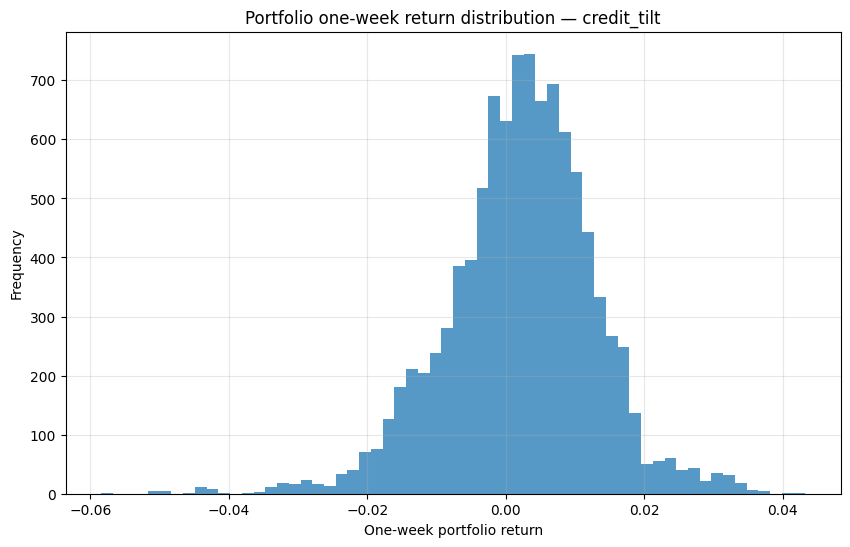

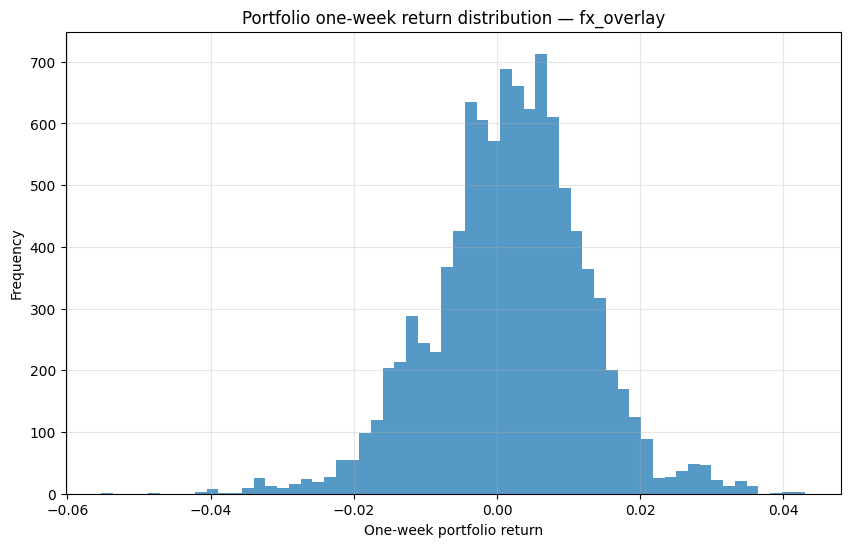

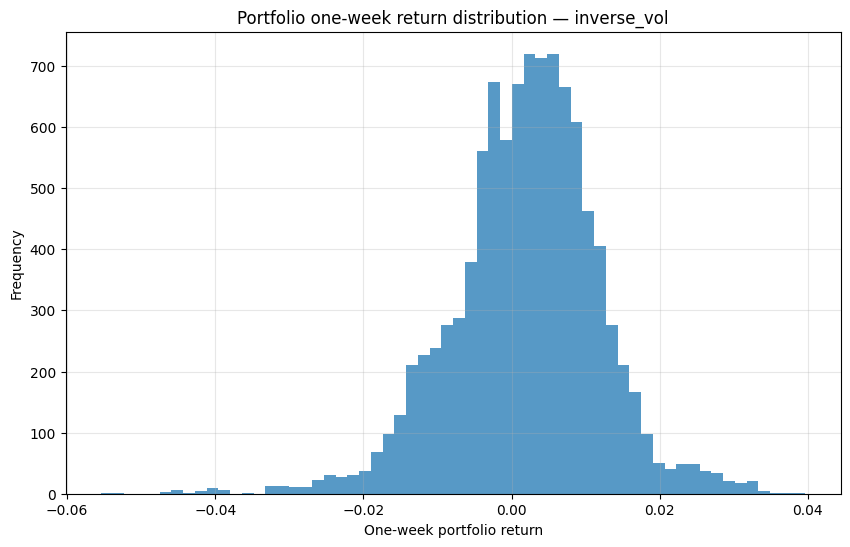

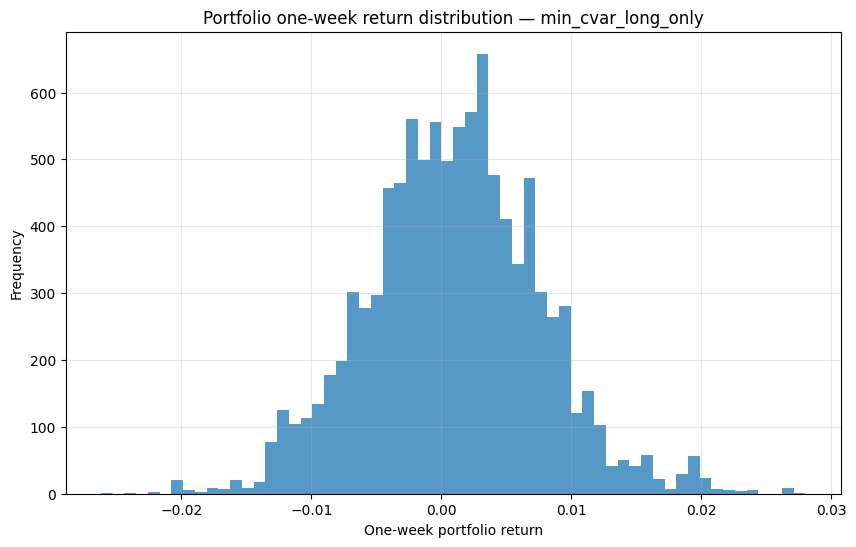

,weight,avg_tail_return_contribution,avg_tail_loss_contribution,share_of_portfolio_ES_loss
Ticker,,,,
CORP_BBB_7Y,0.454371,-0.005755,0.005755,0.453839
FXFWD_EURUSD_3M,0.378800,-0.004806,0.004806,0.379056
CORP_BB_5Y,0.122103,-0.001547,0.001547,0.121972
XOM,0.037022,-0.000475,0.000475,0.037439
MSFT,0.005451,-0.000069,0.000069,0.005441
JPM,0.002253,-0.000029,0.000029,0.002254
HD,0.000000,0.000000,-0.000000,-0.000000
PG,0.000000,0.000000,-0.000000,-0.000000
JNJ,0.000000,0.000000,-0.000000,-0.000000


In [16]:

# Portfolio-level distributions and weighted tail contributions
for name, port_ret in portfolio_returns.items():
    plot_histogram(port_ret, f"Portfolio one-week return distribution — {name}", "One-week portfolio return")

tail_table = tail_contribution_table(
    portfolio_return=portfolio_returns["min_cvar_long_only"],
    instrument_returns=instrument_returns,
    weights=portfolio_weights["min_cvar_long_only"],
    alpha=CVAR_ALPHA,
)

display(tail_table)


## 6. Notes, limitations, and extensions

### Current stable release

The current stable release is the **one-week equity/rates/credit/FX scenario and horizon-repricing engine** with joint block-bootstrap dynamics.

This is the version intended for the public repository and résumé use. It is the most balanced version so far in terms of scope, calibration, and interpretability.

### Optional crisis-tail overlay

The common ICE BofA OAS / equity / FX sample is relatively short and does not contain a full crisis cycle. To avoid pretending that a calm empirical window can generate crisis tails on its own, the notebook includes an optional crisis-tail overlay calibrated from long-history Moody's Baa/Aaa credit-spread data.

The crisis overlay is intentionally optional. With `CRISIS_MODE = "none"`, the engine remains calibrated to the common sample. With a crisis mode enabled, the joint innovation distribution is stressed to produce fatter downside tails.

### Honest limitations

This is a research prototype, not a production system.

Main limitations:

- the common equity/rates/credit/FX sample is short because the available OAS history is limited;
- rating-bucket OAS series are a credit-quality curve, not a full maturity-specific credit spread surface;
- the Treasury pricer treats interpolated CMT par yields as continuously compounded zero rates, which is a declared approximation;
- the FX-forward convention is simplified and intended for horizon-risk analysis, not production FX pricing;
- the 1Y migration/default extension is not part of the stable mainline because its long-horizon dynamics still require calibration work;
- the notebook is still notebook-first rather than a fully modular package.

### Research extensions

Natural next extensions include:

1. a separate one-year branch with block-specific dynamics for equity, rates, credit, FX, and migration/default;
2. mean-reverting level/slope/curvature dynamics for rates and credit spreads;
3. shrinkage of long-horizon expected returns;
4. decomposition of corporate-bond P&L into Treasury, spread, migration/default, coupon, and recovery components;
5. a package-style refactor into `src/` modules with tests and cached data snapshots.
